# Greedy Interaction Flux Balance Analysis (giFBA):
This notebook will walkthrough the process for utilizing the giFBA extension for cobrapy.

***
## Install Information
### Dependencies
- python $\geq$ 3.8
- cobra $\geq$ 0.27.0
- numpy $\geq$ 1.21
- pandas $\geq$ 1.3
- matplotlib $\geq$ UNKNOWN

### Install
From PyPI:<br>
`pip install gifba`

From Github:<br>
`pip install "git+https://github.com/m-3-lab/giFBA.git@main#subdirectory=package"\`

## giFBA Formula
$f_{n+1, j} = f_{n, j} + \sum_i V_{i, j}(a_i, f_{n, j}, S_i)$ <br>

Variables:
- $n$: Iteration Index
- $i$: Model Index
- $j$: Metabolite Index
- $f_{n, j}$: Media Fluxes
- $V_{i,j}$: Scaled Organism Fluxes
- $a_i$: Relative Abundance
- $S_i$: Model Stoichiometric Matrix



$V_{i,j} = a_i * v_{i, j}$ <br>

$$\begin{align*}
v_{i,j} &= \arg \max c^Tv \\
s.t.& \quad S_i v_i = 0 \\
& \quad \frac{1}{a_i} f_{n, j} \leq v_{i, j} \leq ub \\
\end{align*}$$




# Simple Example giFBA
## Import Package & Models
The package contains the simple communities and media as described in the publication.

## Simulation 1a: Simple Single Organism
![Sim 1a Diagram](Model_Diagrams/sim1a_diagram.png)

![Model Diagrams Legend](Model_Diagrams/legend.png)


In [24]:
import gifba

# load models and media:
model, media = gifba.utils.load_simple_models("1a") # sim. 1a

print("Model type:", type(model)," shape:", len(model))
print("Media", media)

Model type: <class 'list'>  shape: 1
Media {'EX_A(e)': -10}


Note the format for Models & Media:
- Models: list of cobrapy models
- Media: Dictionary with key: value > Exchange Reaction ID: available flux amount


## Creating Community Class & Running giFBA:
Community: Class representation for giFBA community model

`class gifba.community.Community(model: [cb.Model, list of cb.Model], media: [dict], rel_abund: Optional[None, str, np.ndarray, list] = None, iters: Optional[None, int, float] = None, objective: Optional[None, str] = None, early_stop: Optional[None, bool] = None, v: Optional[None, bool] = None)`<br>
> Class representation for giFBA community model<br><br>

> **Parameters** <br>
> - **model**(*cb.Model or list of cb.Model*) - Single cobra model or list of cobra models in the community to analyze. 
> - **media**(*dict*) - Dictionary with exchange reaction ids (str) as key, absolute value of lower bound (float) as value.
> - **rel_abund**(*str, np.ndarray, list, None, optional*) - Relative abundance of the community. If None or "equal", will automatically default to $\frac{1}{n_{models}}$. If the sum of floats is greater than 1.0, **rel_abund** will automatically normalize values.
> - **iters**(*int, float, None, optional*) - Maximum number of iterations to run. Must be positive. If None, automatically set to 10 iterations.
> - **objective**(*str, None, optional*) - Method of running FBA. Must be "pfba" or "fba" or None. If None, "pfba" is chosen. "pfba" will utilize parsimonious FBA via `cb.flux_analysis.pfba`. "fba" will utilize `cb.model.optimize`.
> - **early_stop**(*bool, None, optional*) - Whether to check convergence or not. If None, will default to True to reduce computational load.
> - **v**(*bool, None, optional*) - Verbose outputs for iteration progress, automatic parameter changes, early stopping check, adjustment for bounds (if competition). If None, False will be declared.

> **Attributes**<br>
> - will go back and edit this
> -
>

> **Methods**<br>
> - will go back and edit this
> -


In [25]:
# initialize community
community = gifba.gifbaObject(model, media) # default relative abundance is "equal" or [1/n, ..., 1/n]

# run iterations
media_flux, org_flux = community.run_gifba(iters=5, method="pfba", flow = 0.5,   v=True)

Read LP format model from file /tmp/tmpxrdddeym.lp
Reading time = 0.00 seconds
: 4 rows, 10 columns, 16 nonzeros


TypeError: gifbaObject.run_gifba() got an unexpected keyword argument 'flow'

In [ ]:
#plot model results
import matplotlib.pyplot as plt
import numpy as np

bio1_gifba = np.cumsum(org_flux.loc[0, :]["EX_Bio(e)"])
plt.plot(bio1_gifba, lw=0, marker="o", color="b", label="giFBA Result", zorder=3)

# compared to cobrapy FBA
for ex, flux in media.items():
    model[0].exchanges.get_by_id(ex).lower_bound = flux
bio1_fba = model[0].optimize().objective_value
plt.plot([bio1_fba]*community.iters, color='r', label='FBA Result', zorder=2)

axis_lab_size = 14
plt.grid()
plt.xlabel("Iteration", fontsize=axis_lab_size)
plt.xticks(np.arange(0, community.iters, 1))
plt.ylabel(r"Biomass Flux ($\frac{g_1}{g_T \cdot hr}$)", fontsize=axis_lab_size)
# plt.ylim(0, 25)
plt.legend(fontsize=11, loc='upper center', bbox_to_anchor=(0.5, 1.125), ncol=2) 

plt.savefig("Results/giFBA_Simple/gifba_sim1a.svg", bbox_inches='tight')

KeyError: 'exchangeBio1'

## Simulation 1b: Single Organism with "Self" Cross-Feeding
![Sim 1b Diagram](Model_Diagrams/sim1b_diagram.png)

In [27]:
import gifba

# load models and media:
model, media = gifba.utils.load_simple_models("1b") # sim. 1b

# initialize community
community = gifba.gifbaObject(model, media)
# run iterations
media_flux, org_flux = community.run_gifba(iters=5, method="pfba",   v=True)


Read LP format model from file /tmp/tmpnzfsg1q9.lp
Reading time = 0.00 seconds
: 6 rows, 16 columns, 28 nonzeros

Iteration: 0

Iteration: 1

Iteration: 2
Converged at iteration 2
Model is periodic and average of the last 1 iterations will be used for flux calculations.


In [ ]:
#plot model results
import matplotlib.pyplot as plt
import numpy as np

bio1_gifba = np.cumsum(org_flux.loc[0, :]["EX_Bio(e)"])
plt.plot(bio1_gifba, lw=0, marker="o", color="b", label="giFBA Result", zorder=3)

# compared to cobrapy FBA
for ex, flux in media.items():
    model[0].exchanges.get_by_id(ex).lower_bound = flux
bio1_fba = model[0].optimize().objective_value
plt.plot([bio1_fba]*community.iters, color='r', label='FBA Result', zorder=2)

axis_lab_size = 14
plt.grid()
plt.xlabel("Iteration", fontsize=axis_lab_size)
plt.xticks(np.arange(0, community.iters, 1))
plt.ylabel(r"Biomass Flux ($\frac{g_1}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.ylim(0, 25)
plt.legend(fontsize=11, loc='upper center', bbox_to_anchor=(0.5, 1.125), ncol=2) 

plt.savefig("Results/giFBA_Simple/gifba_sim1b.svg", bbox_inches='tight')

KeyError: 'exchangeBio1'

## Simulation 1c: Non-interacting Community with 2 Organisms
![Sim 1c Diagram](Model_Diagrams/sim1c_diagram.png)

In [19]:
import gifba

# load models and media:
sim = "1c"
models, media = gifba.utils.load_simple_models(sim) # sim. 1c

# initialize community
community = gifba.gifbaObject(models, media)
# run iterations
media_flux, org_flux = community.run_gifba(iters=5, method="pfba", v=True)


Read LP format model from file /tmp/tmpqda3ujij.lp
Reading time = 0.00 seconds
: 4 rows, 10 columns, 16 nonzeros
Read LP format model from file /tmp/tmpa_1s8j2d.lp
Reading time = 0.00 seconds
: 4 rows, 10 columns, 16 nonzeros



Iteration: 0

Iteration: 1

Iteration: 2
Converged at iteration 2
Model is periodic and average of the last 1 iterations will be used for flux calculations.


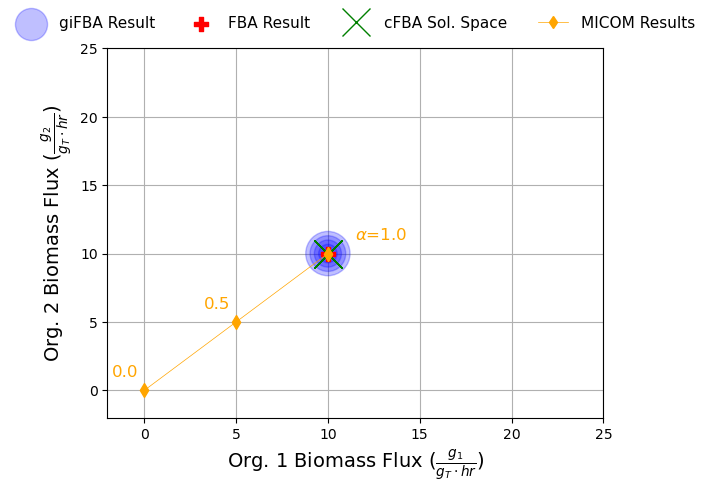

In [21]:
#plot model results
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# sizes for markers
fba_marker_size, cfba_marker_size, micom_marker_size = 100, 20, 50
gifba_marker_sizes = np.linspace(18, 4, community.iters)**2 * np.pi
micom_line_width = 0.5
colors = ["b", "r", "g", "orange"] # gifba, FBA, cFBA, MICOM


# plot giFBA results
bio1_gifba = community.org_fluxes.loc[0, :]["EX_Bio(e)"]
bio2_gifba = community.org_fluxes.loc[1, :]["EX_Bio(e)"]
plt.scatter(bio1_gifba, bio2_gifba, 
            color=colors[0],
            marker="o", 
            s=gifba_marker_sizes, 
            alpha=0.25,
            label="giFBA Result",
            zorder = 2)


# compared to cobrapy FBA
models, media = gifba.utils.load_simple_models(sim) # reload models (since giFBA changed them)
for model in models:
    for ex in model.exchanges:
        model.exchanges.get_by_id(ex.id).lower_bound = 0
for ex, flux in media.items():
    if ex in models[0].exchanges:
        models[0].exchanges.get_by_id(ex).lower_bound = flux
for ex, flux in media.items():
    if ex in models[1].exchanges:
        models[1].exchanges.get_by_id(ex).lower_bound = flux
bio1_fba = models[0].optimize().objective_value
bio2_fba = models[1].optimize().objective_value
plt.scatter(bio1_fba, bio2_fba, 
            color=colors[1], 
            marker="P", 
            s=fba_marker_size,
            label='FBA Result',
            zorder=3)


# compared to cFBA
cfba = pd.read_csv(f"Results/cFBA/cFBA_results_sim{sim}.csv", index_col=False)
plt.plot(cfba["First_Org_Flux"], cfba["Second_Org_Max_Flux"],
            color=colors[2], 
            marker="x", 
            ms=cfba_marker_size,  
            lw=0, 
            label='cFBA Sol. Space',
            zorder=3)


# compared to MICOM
micom = pd.read_csv("Results/micom_results.csv", index_col=0)
micom = micom.loc[sim]
plt.plot(micom["Org1_growth"], micom["Org2_growth"],
            color=colors[3], 
            lw=micom_line_width, 
            ms=micom_marker_size,
            zorder=3)

# label MICOM tradeoff points (only some)
micom_tradeoffs = [0.0, 0.5]
for alpha_tradeoff in micom_tradeoffs:
    posx = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org1_growth"].values[0]
    posy = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org2_growth"].values[0]
    plt.text(posx-1.75, posy+1, 
            str(alpha_tradeoff),
            fontsize=12, 
            zorder=3, 
            color=colors[3])
    plt.scatter(posx, posy, 
                s=micom_marker_size, 
                c=colors[3], 
                marker="d", 
                zorder=3)
alpha_tradeoff = 1.0
posx = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org1_growth"].values[0]
posy = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org2_growth"].values[0]
plt.text(posx+1.5, posy+1, 
        r"$\alpha$=1.0",
        fontsize=12, 
        zorder=3, 
        color=colors[3])
plt.scatter(posx, posy, 
            s=micom_marker_size, 
            c=colors[3], 
            marker="d", 
            zorder=3)

# create custom legend entry
micom_handle = plt.Line2D([0], [0], color=colors[3], lw=micom_line_width, marker="d", label='MICOM Results')
handles, labels = plt.gca().get_legend_handles_labels() # pull original legend
handles.append(micom_handle) # add new legend entry
labels.append("MICOM Results") # add new legend entry
plt.legend(handles=handles, labels=labels,
           fontsize=11, loc='upper center', bbox_to_anchor=(0.5, 1.125), ncol=4, frameon=False) 

# annotate
axis_lab_size = 14
plt.grid(zorder=0)
plt.xlabel(r"Org. 1 Biomass Flux ($\frac{g_1}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.ylabel(r"Org. 2 Biomass Flux ($\frac{g_2}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.xlim(-2, 25)
plt.ylim(-2, 25)

plt.savefig(f"Results/giFBA_Simple/gifba_sim{sim}.svg", bbox_inches='tight')

## Simulation 2a: Simple Competition
![Sim 2a Diagram](Model_Diagrams/sim2a_diagram.png)

In [2]:
import gifba

# load models and media:
sim = "2a"
models, media = gifba.utils.load_simple_models(sim) # sim. 2a

# initialize community
community = gifba.gifbaObject(models, media)

# run iterations
media_flux, org_flux = community.run_gifba(iters=5, method="pfba", v=True)


Read LP format model from file /tmp/tmp6mf19wj9.lp
Reading time = 0.00 seconds
: 4 rows, 10 columns, 16 nonzeros
Read LP format model from file /tmp/tmpetp_ysvs.lp
Reading time = 0.00 seconds
: 4 rows, 10 columns, 16 nonzeros

Iteration: 0
EX_A(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 1
EX_A(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 2
EX_A(e) over-consumed by factor of 2.000000000000 (rerun count: 0)
Converged at iteration 2
Model is periodic and average of the last 1 iterations will be used for flux calculations.


If both models are optimized to consume a metabolite, there is a chance more metabolite will be taken up than is available. This is called the overshoot, which is the ratio of total consumed flux of metabolites to available flux in the media. If any overshoot variable is greater than 1, then more metabolite was consumed than is available. In this case, the algorithm will adjust all lower bounds relative to the metabolite with the maximum uptake. The adjustment factor follows:<br>


$lb_j = \frac{V_{i, j} f_{n, j}}{\sum_i a_i V_{i, j^*}}$
 
 **Variables**:
 > - $lb_j$ : Lower Bound for Exchange of Metabolite $j$
 > - $j^* = \arg \max_j OS_j$ : Metabolite of Maximum Overshoot
 > - $OS_j = \frac{\sum_i V_{i,j}}{f_{n, j}}$ : Overshoot Factor

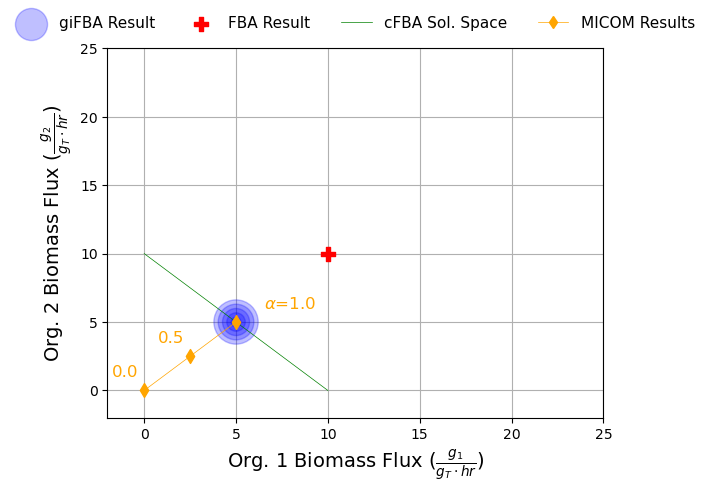

In [3]:
#plot model results
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# sizes for markers
fba_marker_size, cfba_marker_size, micom_marker_size = 100, 20, 50
gifba_marker_sizes = np.linspace(18, 4, community.iters)**2 * np.pi
micom_line_width = 0.5
colors = ["b", "r", "g", "orange"] # gifba, FBA, cFBA, MICOM


# plot giFBA results
bio1_gifba = community.org_fluxes.loc[0, :]["EX_Bio(e)"]
bio2_gifba = community.org_fluxes.loc[1, :]["EX_Bio(e)"]
plt.scatter(bio1_gifba, bio2_gifba, 
            color=colors[0],
            marker="o", 
            s=gifba_marker_sizes, 
            alpha=0.25,
            label="giFBA Result",
            zorder = 2)


# compared to cobrapy FBA
models, media = gifba.utils.load_simple_models(sim) # reload models (since giFBA changed them)
for model in models:
    for ex in model.exchanges:
        model.exchanges.get_by_id(ex.id).lower_bound = 0
for ex, flux in media.items():
    if ex in models[0].exchanges:
        models[0].exchanges.get_by_id(ex).lower_bound = flux
for ex, flux in media.items():
    if ex in models[1].exchanges:
        models[1].exchanges.get_by_id(ex).lower_bound = flux
bio1_fba = models[0].optimize().objective_value
bio2_fba = models[1].optimize().objective_value
plt.scatter(bio1_fba, bio2_fba, 
            color=colors[1], 
            marker="P", 
            s=fba_marker_size,
            label='FBA Result',
            zorder=3)


# compared to cFBA
cfba = pd.read_csv(f"Results/cFBA/cFBA_results_sim{sim}.csv", index_col=False)
plt.plot(cfba["First_Org_Flux"], cfba["Second_Org_Max_Flux"],
            color=colors[2], 
            lw=micom_line_width, 
            label='cFBA Sol. Space',
            zorder=3)


# compared to MICOM
micom = pd.read_csv("Results/micom_results.csv", index_col=0)
micom = micom.loc[sim]
plt.plot(micom["Org1_growth"], micom["Org2_growth"],
            color=colors[3], 
            lw=micom_line_width, 
            ms=micom_marker_size,
            zorder=3)

# label MICOM tradeoff points (only some)
micom_tradeoffs = [0.0, 0.5]
for alpha_tradeoff in micom_tradeoffs:
    posx = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org1_growth"].values[0]
    posy = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org2_growth"].values[0]
    plt.text(posx-1.75, posy+1, str(alpha_tradeoff),
            fontsize=12, zorder=3, color=colors[3])
    plt.scatter(posx, posy, 
                s=micom_marker_size, c=colors[3], marker="d", zorder=3)
alpha_tradeoff = 1.0
posx = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org1_growth"].values[0]
posy = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org2_growth"].values[0]
plt.text(posx+1.5, posy+1, r"$\alpha$=1.0",
        fontsize=12, zorder=3, color=colors[3])
plt.scatter(posx, posy, 
            s=micom_marker_size, c=colors[3], marker="d", zorder=3)

# create custom legend entry
micom_handle = plt.Line2D([0], [0], color=colors[3], lw=micom_line_width, marker="d", label='MICOM Results')
handles, labels = plt.gca().get_legend_handles_labels() # pull original legend
handles.append(micom_handle) # add new legend entry
labels.append("MICOM Results") # add new legend entry
plt.legend(handles=handles, labels=labels,
           fontsize=11, loc='upper center', bbox_to_anchor=(0.5, 1.125), ncol=4, frameon=False) 

# annotate
axis_lab_size = 14
plt.grid(zorder=0)
plt.xlabel(r"Org. 1 Biomass Flux ($\frac{g_1}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.ylabel(r"Org. 2 Biomass Flux ($\frac{g_2}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.xlim(-2, 25)
plt.ylim(-2, 25)

plt.savefig(f"Results/giFBA_Simple/gifba_sim{sim}.svg", bbox_inches='tight')

Simple FBA, cannot handle community interactions unless modified for compartmentalized FBA.

## Simulation 2b: Simple Competition (Unequal Abundances)
![Sim 2b Diagram](Model_Diagrams/sim2b_diagram.png)

Now we can adjust the relative abundance of the community and see the difference

In [1]:
import gifba

# load models and media:
sim = "2b"
rel_abund = [0.2, 0.8]
models, media = gifba.utils.load_simple_models(sim) # sim. 2b
# initialize community
community = gifba.gifbaObject(models, media, rel_abund=rel_abund)  # relative abundances of each organism
# run iterations
media_flux, org_flux = community.run_gifba(iters=5, method="pfba", v=True)

Set parameter Username
Set parameter LicenseID to value 2773321
Academic license - for non-commercial use only - expires 2027-02-01
Read LP format model from file /tmp/tmpwvy2p5y4.lp
Reading time = 0.00 seconds
: 4 rows, 10 columns, 16 nonzeros
Read LP format model from file /tmp/tmpr47v1_1y.lp
Reading time = 0.00 seconds
: 4 rows, 10 columns, 16 nonzeros

Iteration: 0
EX_A(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 1
EX_A(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 2
EX_A(e) over-consumed by factor of 2.000000000000 (rerun count: 0)
Converged at iteration 2
Model is periodic and average of the last 1 iterations will be used for flux calculations.


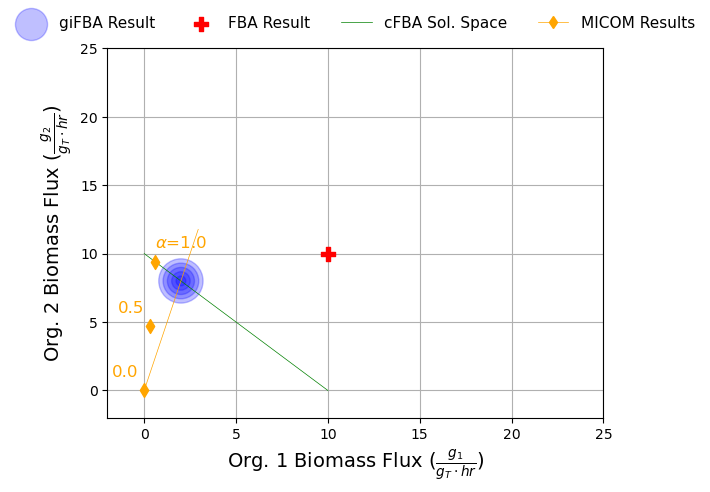

In [ ]:
#plot model results
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# sizes for markers
fba_marker_size, cfba_marker_size, micom_marker_size = 100, 20, 50
gifba_marker_sizes = np.linspace(18, 4, community.iters)**2 * np.pi
micom_line_width = 0.5
colors = ["b", "r", "g", "orange"] # gifba, FBA, cFBA, MICOM


# plot giFBA results
bio1_gifba = community.org_fluxes.loc[0, :]["EX_Bio(e)"]
bio2_gifba = community.org_fluxes.loc[1, :]["EX_Bio(e)"]
plt.scatter(bio1_gifba, bio2_gifba, 
            color=colors[0],
            marker="o", 
            s=gifba_marker_sizes, 
            alpha=0.25,
            label="giFBA Result",
            zorder = 2)


# compared to cobrapy FBA
models, media = gifba.utils.load_simple_models(sim) # reload models (since giFBA changed them)
for model in models:
    for ex in model.exchanges:
        model.exchanges.get_by_id(ex.id).lower_bound = 0
for ex, flux in media.items():
    if ex in models[0].exchanges:
        models[0].exchanges.get_by_id(ex).lower_bound = flux
for ex, flux in media.items():
    if ex in models[1].exchanges:
        models[1].exchanges.get_by_id(ex).lower_bound = flux
bio1_fba = models[0].optimize().objective_value
bio2_fba = models[1].optimize().objective_value
plt.scatter(bio1_fba, bio2_fba, 
            color=colors[1], 
            marker="P", 
            s=fba_marker_size,
            label='FBA Result',
            zorder=3)


# compared to cFBA
cfba = pd.read_csv(f"Results/cFBA/cFBA_results_sim{sim}.csv", index_col=False)
plt.plot(cfba["First_Org_Flux"], cfba["Second_Org_Max_Flux"],
            color=colors[2], 
            lw=micom_line_width, 
            label='cFBA Sol. Space',
            zorder=3)


# compared to MICOM (specific rates interpretation)
micom = pd.read_csv("Results/micom_results.csv", index_col=0)
micom = micom.loc[sim]
plt.plot(micom["Org1_growth"], micom["Org2_growth"],
            color=colors[3], 
            lw=micom_line_width, 
            ms=micom_marker_size,
            zorder=3)

# label MICOM tradeoff points (only some)
micom_tradeoffs = [0.0, 0.5]
for alpha_tradeoff in micom_tradeoffs:
    posx = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org1_growth"].values[0]
    posy = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org2_growth"].values[0]
    plt.text(posx-1.75, posy+1, 
            str(alpha_tradeoff),
            fontsize=12, 
            zorder=3, 
            color=colors[3])
    plt.scatter(posx, posy, 
                s=micom_marker_size, 
                c=colors[3], 
                marker="d", 
                zorder=3)
alpha_tradeoff = 1.0
posx = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org1_growth"].values[0]
posy = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org2_growth"].values[0]
plt.text(posx+0, posy+1, 
        r"$\alpha$=1.0",
        fontsize=12, 
        zorder=3, 
        color=colors[3])
plt.scatter(posx, posy, 
            s=micom_marker_size, 
            c=colors[3], 
            marker="d", 
            zorder=3)

# create custom legend entry
micom_handle = plt.Line2D([0], [0], color=colors[3], lw=micom_line_width, marker="d", label='MICOM Results')
handles, labels = plt.gca().get_legend_handles_labels() # pull original legend
handles.append(micom_handle) # add new legend entry
labels.append("MICOM Results") # add new legend entry

# compared to MICOM (relative rates interpretation)
plt.plot(micom["Org1_growth"]/rel_abund[0], micom["Org2_growth"]/rel_abund[1],
            color=colors[3], 
            lw=micom_line_width, 
            ms=micom_marker_size,
            zorder=3)

# label MICOM tradeoff points (only some)
micom_tradeoffs = [0.0, 0.5]
for alpha_tradeoff in micom_tradeoffs:
    posx = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org1_growth"].values[0]
    posy = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org2_growth"].values[0]
    plt.text(posx-1.75, posy+1, 
            str(alpha_tradeoff),
            fontsize=12, 
            zorder=3, 
            color=colors[3])
    plt.scatter(posx, posy, 
                s=micom_marker_size, 
                c=colors[3], 
                marker="d", 
                zorder=3)
alpha_tradeoff = 1.0
posx = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org1_growth"].values[0]
posy = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org2_growth"].values[0]
plt.text(posx+0, posy+1, 
        r"$\alpha$=1.0",
        fontsize=12, 
        zorder=3, 
        color=colors[3])
plt.scatter(posx, posy, 
            s=micom_marker_size, 
            c=colors[3], 
            marker="d", 
            zorder=3)

# create custom legend entry
micom_handle = plt.Line2D([0], [0], color=colors[3], lw=micom_line_width, marker="d", label='MICOM Results')
handles, labels = plt.gca().get_legend_handles_labels() # pull original legend
handles.append(micom_handle) # add new legend entry
labels.append("MICOM Results") # add new legend entry
plt.legend(handles=handles, labels=labels,
           fontsize=11, loc='upper center', bbox_to_anchor=(0.5, 1.125), ncol=4, frameon=False) 

# annotate
axis_lab_size = 14
plt.grid(zorder=0)
plt.xlabel(r"Org. 1 Biomass Flux ($\frac{g_1}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.ylabel(r"Org. 2 Biomass Flux ($\frac{g_2}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.xlim(-2, 25)
plt.ylim(-2, 25)

plt.savefig(f"Results/giFBA_Simple/gifba_sim{sim}.svg", bbox_inches='tight')

We expect an organism with 4 times the abundance, to have an initial biomass flux that is 4 times its competitor.

## Simulation 2c: Simple Competition (Unequal Rates)
![Sim 2c Diagram](Model_Diagrams/sim2c_diagram.png)

In [6]:
import gifba

# load models and media:
sim = "2c"
models, media = gifba.utils.load_simple_models(sim) # sim. 2c

# initialize community
community = gifba.gifbaObject(models, media)
# run iterations
media_flux, org_flux = community.run_gifba(iters=5, method="pfba", v=True)


Read LP format model from file /tmp/tmplzjnooui.lp
Reading time = 0.00 seconds
: 4 rows, 10 columns, 16 nonzeros
Read LP format model from file /tmp/tmpcbu5mw5k.lp
Reading time = 0.00 seconds
: 4 rows, 10 columns, 16 nonzeros

Iteration: 0

Iteration: 1

Iteration: 2
Converged at iteration 2
Model is periodic and average of the last 1 iterations will be used for flux calculations.


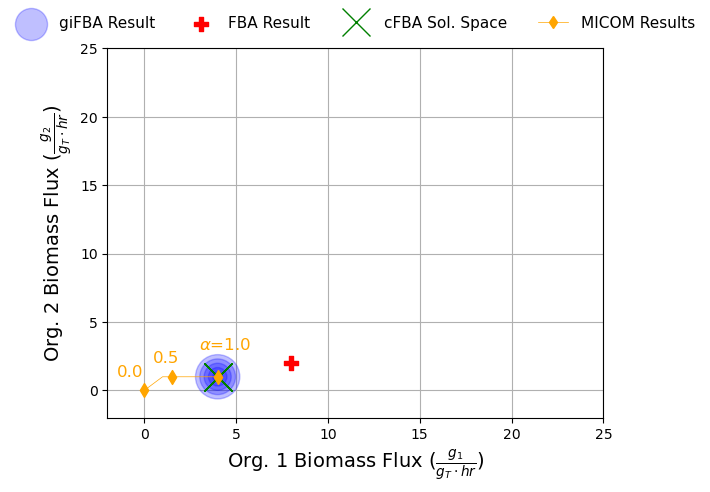

In [7]:
#plot model results
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# sizes for markers
fba_marker_size, cfba_marker_size, micom_marker_size = 100, 20, 50
gifba_marker_sizes = np.linspace(18, 4, community.iters)**2 * np.pi
micom_line_width = 0.5
colors = ["b", "r", "g", "orange"] # gifba, FBA, cFBA, MICOM


# plot giFBA results
bio1_gifba = community.org_fluxes.loc[0, :]["EX_Bio(e)"]
bio2_gifba = community.org_fluxes.loc[1, :]["EX_Bio(e)"]
plt.scatter(bio1_gifba, bio2_gifba, 
            color=colors[0],
            marker="o", 
            s=gifba_marker_sizes, 
            alpha=0.25,
            label="giFBA Result",
            zorder = 2)


# compared to cobrapy FBA
models, media = gifba.utils.load_simple_models(sim) # reload models (since giFBA changed them)
for model in models:
    for ex in model.exchanges:
        model.exchanges.get_by_id(ex.id).lower_bound = 0
for ex, flux in media.items():
    if ex in models[0].exchanges:
        models[0].exchanges.get_by_id(ex).lower_bound = flux
for ex, flux in media.items():
    if ex in models[1].exchanges:
        models[1].exchanges.get_by_id(ex).lower_bound = flux
bio1_fba = models[0].optimize().objective_value
bio2_fba = models[1].optimize().objective_value
plt.scatter(bio1_fba, bio2_fba, 
            color=colors[1], 
            marker="P", 
            s=fba_marker_size,
            label='FBA Result',
            zorder=3)


# compared to cFBA
cfba = pd.read_csv(f"Results/cFBA/cFBA_results_sim{sim}.csv", index_col=False)
plt.plot(cfba["First_Org_Flux"], cfba["Second_Org_Max_Flux"],
            color=colors[2], 
            marker="x", 
            ms=cfba_marker_size,  
            lw=0, 
            label='cFBA Sol. Space',
            zorder=3)


# compared to MICOM
micom = pd.read_csv("Results/micom_results.csv", index_col=0)
micom = micom.loc[sim]
plt.plot(micom["Org1_growth"], micom["Org2_growth"],
            color=colors[3], 
            lw=micom_line_width, 
            ms=micom_marker_size,
            zorder=3)

# label MICOM tradeoff points (only some)
alpha_tradeoff = 0.0
posx = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org1_growth"].values[0]
posy = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org2_growth"].values[0]
plt.text(posx-1.5, posy+1, str(alpha_tradeoff),
            fontsize=12, zorder=3, color=colors[3])
plt.scatter(posx, posy, 
            s=micom_marker_size, c=colors[3], marker="d", zorder=3)

alpha_tradeoff = 0.5
posx = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org1_growth"].values[0]
posy = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org2_growth"].values[0]
plt.text(posx-1, posy+1, str(alpha_tradeoff),
        fontsize=12, zorder=3, color=colors[3])
plt.scatter(posx, posy, 
            s=micom_marker_size, c=colors[3], marker="d", zorder=3)

alpha_tradeoff = 1.0
posx = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org1_growth"].values[0]
posy = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org2_growth"].values[0]
plt.text(posx-1, posy+2, r"$\alpha$=1.0",
        fontsize=12, zorder=3, color=colors[3])
plt.scatter(posx, posy, 
            s=micom_marker_size, c=colors[3], marker="d", zorder=3)

# create custom legend entry
micom_handle = plt.Line2D([0], [0], color=colors[3], lw=micom_line_width, marker="d", label='MICOM Results')
handles, labels = plt.gca().get_legend_handles_labels() # pull original legend
handles.append(micom_handle) # add new legend entry
labels.append("MICOM Results") # add new legend entry
plt.legend(handles=handles, labels=labels,
           fontsize=11, loc='upper center', bbox_to_anchor=(0.5, 1.125), ncol=4, frameon=False) 

# annotate
axis_lab_size = 14
plt.grid(zorder=0)
plt.xlabel(r"Org. 1 Biomass Flux ($\frac{g_1}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.ylabel(r"Org. 2 Biomass Flux ($\frac{g_2}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.xlim(-2, 25)
plt.ylim(-2, 25)

plt.savefig(f"Results/giFBA_Simple/gifba_sim{sim}.svg", bbox_inches='tight')

## Simulation 2d: Simple Competition (Unequal Rates)
![Sim 2d Diagram](Model_Diagrams/sim2d_diagram.png)

In [8]:
import gifba

# load models and media:
sim = "2d"
models, media = gifba.utils.load_simple_models(sim) # sim. 2d

# initialize community
community = gifba.gifbaObject(models, media)
# run iterations
media_flux, org_flux = community.run_gifba(iters=5, method="pfba", v=True)


Read LP format model from file /tmp/tmpny_5aoqn.lp
Reading time = 0.00 seconds
: 4 rows, 10 columns, 16 nonzeros
Read LP format model from file /tmp/tmpopocz3no.lp
Reading time = 0.00 seconds
: 4 rows, 10 columns, 16 nonzeros

Iteration: 0

Iteration: 1

Iteration: 2
Converged at iteration 2
Model is periodic and average of the last 1 iterations will be used for flux calculations.


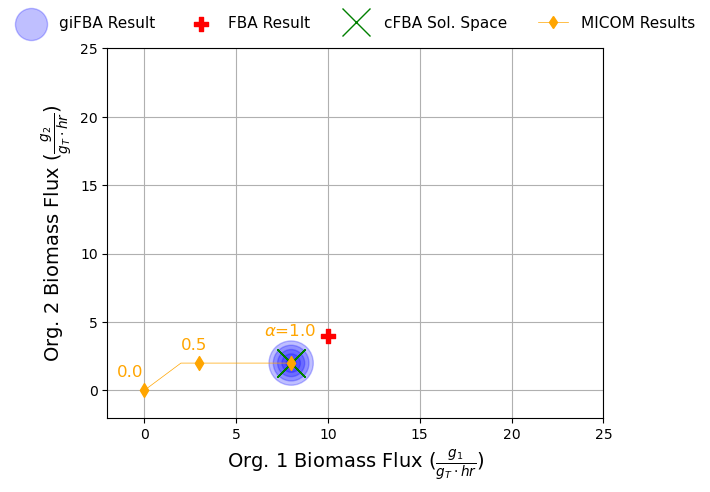

In [9]:
#plot model results
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# sizes for markers
fba_marker_size, cfba_marker_size, micom_marker_size = 100, 20, 50
gifba_marker_sizes = np.linspace(18, 4, community.iters)**2 * np.pi
micom_line_width = 0.5
colors = ["b", "r", "g", "orange"] # gifba, FBA, cFBA, MICOM


# plot giFBA results
bio1_gifba = community.org_fluxes.loc[0, :]["EX_Bio(e)"]
bio2_gifba = community.org_fluxes.loc[1, :]["EX_Bio(e)"]
plt.scatter(bio1_gifba, bio2_gifba, 
            color=colors[0],
            marker="o", 
            s=gifba_marker_sizes, 
            alpha=0.25,
            label="giFBA Result",
            zorder = 2)


# compared to cobrapy FBA
models, media = gifba.utils.load_simple_models(sim) # reload models (since giFBA changed them)
for model in models:
    for ex in model.exchanges:
        model.exchanges.get_by_id(ex.id).lower_bound = 0
for ex, flux in media.items():
    if ex in models[0].exchanges:
        models[0].exchanges.get_by_id(ex).lower_bound = flux
for ex, flux in media.items():
    if ex in models[1].exchanges:
        models[1].exchanges.get_by_id(ex).lower_bound = flux
bio1_fba = models[0].optimize().objective_value
bio2_fba = models[1].optimize().objective_value
plt.scatter(bio1_fba, bio2_fba, 
            color=colors[1], 
            marker="P", 
            s=fba_marker_size,
            label='FBA Result',
            zorder=3)


# compared to cFBA
cfba = pd.read_csv(f"Results/cFBA/cFBA_results_sim{sim}.csv", index_col=False)
plt.plot(cfba["First_Org_Flux"], cfba["Second_Org_Max_Flux"],
            color=colors[2], 
            marker="x", 
            ms=cfba_marker_size,  
            lw=0, 
            label='cFBA Sol. Space',
            zorder=3)


# compared to MICOM
micom = pd.read_csv("Results/micom_results.csv", index_col=0)
micom = micom.loc[sim]
plt.plot(micom["Org1_growth"], micom["Org2_growth"],
            color=colors[3], 
            lw=micom_line_width, 
            ms=micom_marker_size,
            zorder=3)

# label MICOM tradeoff points (only some)
alpha_tradeoff = 0.0
posx = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org1_growth"].values[0]
posy = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org2_growth"].values[0]
plt.text(posx-1.5, posy+1, str(alpha_tradeoff),
            fontsize=12, zorder=3, color=colors[3])
plt.scatter(posx, posy, 
            s=micom_marker_size, c=colors[3], marker="d", zorder=3)

alpha_tradeoff = 0.5
posx = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org1_growth"].values[0]
posy = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org2_growth"].values[0]
plt.text(posx-1, posy+1, str(alpha_tradeoff),
        fontsize=12, zorder=3, color=colors[3])
plt.scatter(posx, posy, 
            s=micom_marker_size, c=colors[3], marker="d", zorder=3)

alpha_tradeoff = 1.0
posx = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org1_growth"].values[0]
posy = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org2_growth"].values[0]
plt.text(posx-1.5, posy+2, r"$\alpha$=1.0",
        fontsize=12, zorder=3, color=colors[3])
plt.scatter(posx, posy, 
            s=micom_marker_size, c=colors[3], marker="d", zorder=3)

# create custom legend entry
micom_handle = plt.Line2D([0], [0], color=colors[3], lw=micom_line_width, marker="d", label='MICOM Results')
handles, labels = plt.gca().get_legend_handles_labels() # pull original legend
handles.append(micom_handle) # add new legend entry
labels.append("MICOM Results") # add new legend entry
plt.legend(handles=handles, labels=labels,
           fontsize=11, loc='upper center', bbox_to_anchor=(0.5, 1.125), ncol=4, frameon=False) 

# annotate
axis_lab_size = 14
plt.grid(zorder=0)
plt.xlabel(r"Org. 1 Biomass Flux ($\frac{g_1}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.ylabel(r"Org. 2 Biomass Flux ($\frac{g_2}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.xlim(-2, 25)
plt.ylim(-2, 25)

plt.savefig(f"Results/giFBA_Simple/gifba_sim{sim}.svg", bbox_inches='tight')

In [10]:
import gifba

# load models and media:
sim="2e"
models, media = gifba.utils.load_simple_models(sim) # sim. 2e

# initialize community
community = gifba.gifbaObject(models, media)
# run iterations
media_flux, org_flux = community.run_gifba(iters=5, method="pfba",   v=True)


Read LP format model from file /tmp/tmpw5_p4kfv.lp
Reading time = 0.00 seconds
: 4 rows, 10 columns, 16 nonzeros
Read LP format model from file /tmp/tmp6fliv0p2.lp
Reading time = 0.00 seconds
: 4 rows, 10 columns, 16 nonzeros

Iteration: 0

Iteration: 1

Iteration: 2
Converged at iteration 2
Model is periodic and average of the last 1 iterations will be used for flux calculations.


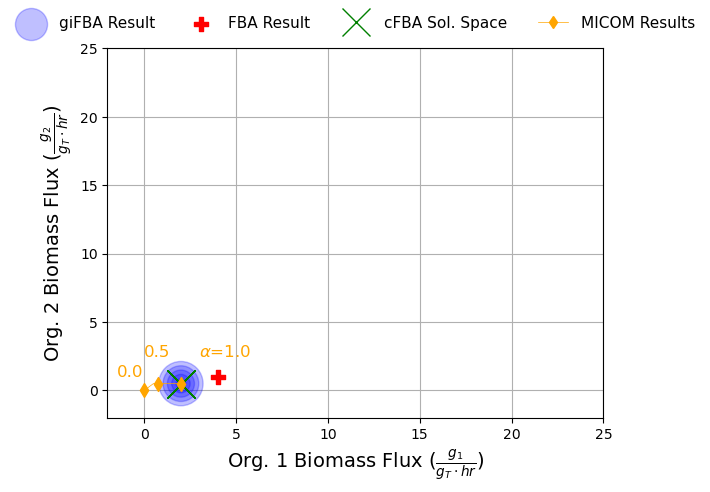

In [11]:
#plot model results
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# sizes for markers
fba_marker_size, cfba_marker_size, micom_marker_size = 100, 20, 50
gifba_marker_sizes = np.linspace(18, 4, community.iters)**2 * np.pi
micom_line_width = 0.5
colors = ["b", "r", "g", "orange"] # gifba, FBA, cFBA, MICOM


# plot giFBA results
bio1_gifba = community.org_fluxes.loc[0, :]["EX_Bio(e)"]
bio2_gifba = community.org_fluxes.loc[1, :]["EX_Bio(e)"]
plt.scatter(bio1_gifba, bio2_gifba, 
            color=colors[0],
            marker="o", 
            s=gifba_marker_sizes, 
            alpha=0.25,
            label="giFBA Result",
            zorder = 2)


# compared to cobrapy FBA
models, media = gifba.utils.load_simple_models(sim) # reload models (since giFBA changed them)
for model in models:
    for ex in model.exchanges:
        model.exchanges.get_by_id(ex.id).lower_bound = 0
for ex, flux in media.items():
    if ex in models[0].exchanges:
        models[0].exchanges.get_by_id(ex).lower_bound = flux
for ex, flux in media.items():
    if ex in models[1].exchanges:
        models[1].exchanges.get_by_id(ex).lower_bound = flux
bio1_fba = models[0].optimize().objective_value
bio2_fba = models[1].optimize().objective_value
plt.scatter(bio1_fba, bio2_fba, 
            color=colors[1], 
            marker="P", 
            s=fba_marker_size,
            label='FBA Result',
            zorder=3)


# compared to cFBA
cfba = pd.read_csv(f"Results/cFBA/cFBA_results_sim{sim}.csv", index_col=False)
plt.plot(cfba["First_Org_Flux"], cfba["Second_Org_Max_Flux"],
            color=colors[2], 
            marker="x", 
            ms=cfba_marker_size,  
            lw=0, 
            label='cFBA Sol. Space',
            zorder=3)


# compared to MICOM
micom = pd.read_csv("Results/micom_results.csv", index_col=0)
micom = micom.loc[sim]
plt.plot(micom["Org1_growth"], micom["Org2_growth"],
            color=colors[3], 
            lw=micom_line_width, 
            ms=micom_marker_size,
            zorder=3)

# label MICOM tradeoff points (only some)
alpha_tradeoff = 0.0
posx = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org1_growth"].values[0]
posy = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org2_growth"].values[0]
plt.text(posx-1.5, posy+1, str(alpha_tradeoff),
            fontsize=12, zorder=3, color=colors[3])
plt.scatter(posx, posy, 
            s=micom_marker_size, c=colors[3], marker="d", zorder=3)

alpha_tradeoff = 0.5
posx = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org1_growth"].values[0]
posy = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org2_growth"].values[0]
plt.text(posx-0.75, posy+2, str(alpha_tradeoff),
        fontsize=12, zorder=3, color=colors[3])
plt.scatter(posx, posy, 
            s=micom_marker_size, c=colors[3], marker="d", zorder=3)

alpha_tradeoff = 1.0
posx = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org1_growth"].values[0]
posy = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org2_growth"].values[0]
plt.text(posx+1, posy+2, r"$\alpha$=1.0",
        fontsize=12, zorder=3, color=colors[3])
plt.scatter(posx, posy, 
            s=micom_marker_size, c=colors[3], marker="d", zorder=3)

# create custom legend entry
micom_handle = plt.Line2D([0], [0], color=colors[3], lw=micom_line_width, marker="d", label='MICOM Results')
handles, labels = plt.gca().get_legend_handles_labels() # pull original legend
handles.append(micom_handle) # add new legend entry
labels.append("MICOM Results") # add new legend entry
plt.legend(handles=handles, labels=labels,
           fontsize=11, loc='upper center', bbox_to_anchor=(0.5, 1.125), ncol=4, frameon=False) 

# annotate
axis_lab_size = 14
plt.grid(zorder=0)
plt.xlabel(r"Org. 1 Biomass Flux ($\frac{g_1}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.ylabel(r"Org. 2 Biomass Flux ($\frac{g_2}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.xlim(-2, 25)
plt.ylim(-2, 25)

plt.savefig(f"Results/giFBA_Simple/gifba_sim{sim}.svg", bbox_inches='tight')

## Simulation 3a: Simple Cross-Feeding Between 2 Organisms
![Sim 3a Diagram](Model_Diagrams/sim3a_diagram.png)

In [12]:
import gifba

# load models and media:
sim = "3a"
models, media = gifba.utils.load_simple_models(sim) # sim. 3a

# initialize community
community = gifba.gifbaObject(models, media)
# run iterations
media_flux, org_flux = community.run_gifba(iters=5, method="pfba",   v=True)



Read LP format model from file /tmp/tmp1cx33uc_.lp
Reading time = 0.00 seconds
: 6 rows, 16 columns, 26 nonzeros
Read LP format model from file /tmp/tmpsn32l2en.lp
Reading time = 0.00 seconds
: 6 rows, 14 columns, 24 nonzeros



Iteration: 0

Iteration: 1

Iteration: 2

Iteration: 3
Converged at iteration 3
Model is periodic and average of the last 1 iterations will be used for flux calculations.


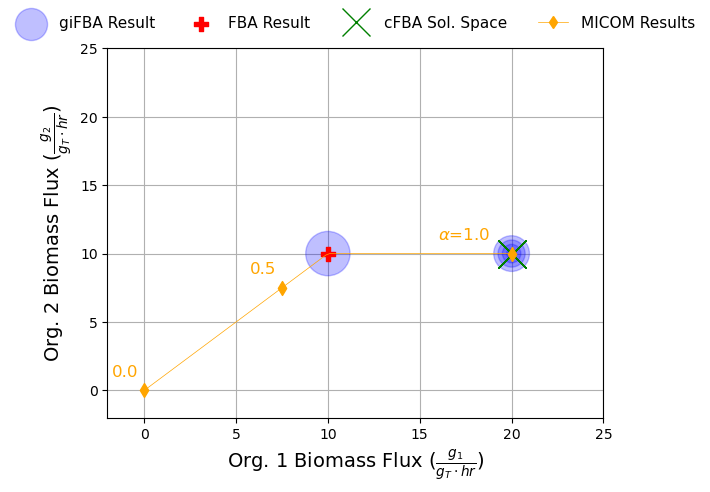

In [13]:
#plot model results
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# sizes for markers
fba_marker_size, cfba_marker_size, micom_marker_size = 100, 20, 50
gifba_marker_sizes = np.linspace(18, 4, community.iters)**2 * np.pi
micom_line_width = 0.5
colors = ["b", "r", "g", "orange"] # gifba, FBA, cFBA, MICOM


# plot giFBA results
bio1_gifba = community.org_fluxes.loc[0, :]["EX_Bio(e)"]
bio2_gifba = community.org_fluxes.loc[1, :]["EX_Bio(e)"]
plt.scatter(bio1_gifba, bio2_gifba, 
            color=colors[0],
            marker="o", 
            s=gifba_marker_sizes, 
            alpha=0.25,
            label="giFBA Result",
            zorder = 2)


# compared to cobrapy FBA
models, media = gifba.utils.load_simple_models(sim) # reload models (since giFBA changed them)
for model in models:
    for ex in model.exchanges:
        model.exchanges.get_by_id(ex.id).lower_bound = 0
for ex, flux in media.items():
    if ex in models[0].exchanges:
        models[0].exchanges.get_by_id(ex).lower_bound = flux
for ex, flux in media.items():
    if ex in models[1].exchanges:
        models[1].exchanges.get_by_id(ex).lower_bound = flux
bio1_fba = models[0].optimize().objective_value
bio2_fba = models[1].optimize().objective_value
plt.scatter(bio1_fba, bio2_fba, 
            color=colors[1], 
            marker="P", 
            s=fba_marker_size,
            label='FBA Result',
            zorder=3)


# compared to cFBA
cfba = pd.read_csv(f"Results/cFBA/cFBA_results_sim{sim}.csv", index_col=False)
plt.plot(cfba["First_Org_Flux"], cfba["Second_Org_Max_Flux"],
            color=colors[2], 
            marker="x", 
            ms=cfba_marker_size,  
            lw=0, 
            label='cFBA Sol. Space',
            zorder=3)


# compared to MICOM
micom = pd.read_csv("Results/micom_results.csv", index_col=0)
micom = micom.loc[sim]
plt.plot(micom["Org1_growth"], micom["Org2_growth"],
            color=colors[3], 
            lw=micom_line_width, 
            ms=micom_marker_size,
            zorder=3)

# label MICOM tradeoff points (only some)
micom_tradeoffs = [0.0, 0.5]
for alpha_tradeoff in micom_tradeoffs:
    posx = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org1_growth"].values[0]
    posy = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org2_growth"].values[0]
    plt.text(posx-1.75, posy+1, str(alpha_tradeoff),
            fontsize=12, zorder=3, color=colors[3])
    plt.scatter(posx, posy, 
                s=micom_marker_size, c=colors[3], marker="d", zorder=3)
alpha_tradeoff = 1.0
posx = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org1_growth"].values[0]
posy = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org2_growth"].values[0]
plt.text(posx-4, posy+1, r"$\alpha$=1.0",
        fontsize=12, zorder=3, color=colors[3])
plt.scatter(posx, posy, 
            s=micom_marker_size, c=colors[3], marker="d", zorder=3)

# create custom legend entry
micom_handle = plt.Line2D([0], [0], color=colors[3], lw=micom_line_width, marker="d", label='MICOM Results')
handles, labels = plt.gca().get_legend_handles_labels() # pull original legend
handles.append(micom_handle) # add new legend entry
labels.append("MICOM Results") # add new legend entry
plt.legend(handles=handles, labels=labels,
           fontsize=11, loc='upper center', bbox_to_anchor=(0.5, 1.125), ncol=4, frameon=False) 

# annotate
axis_lab_size = 14
plt.grid(zorder=0)
plt.xlabel(r"Org. 1 Biomass Flux ($\frac{g_1}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.ylabel(r"Org. 2 Biomass Flux ($\frac{g_2}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.xlim(-2, 25)
plt.ylim(-2, 25)

plt.savefig(f"Results/giFBA_Simple/gifba_sim{sim}.svg", bbox_inches='tight')

Notice that end behavior matches between:
- Simulation 3a, Organism 1 & Simulation 1b
- Simulation 3a, Organism 2 & Simulation 1a

## Simulation 3b: Multi-Step Cross-Feeding
![Sim 3b Diagram](Model_Diagrams/sim3b_diagram.png)

In [14]:
import gifba

# load models and media:
sim = "3b"
models, media = gifba.utils.load_simple_models(sim) # sim. 3b

# initialize community
community = gifba.gifbaObject(models, media)
# run iterations+
media_flux, org_flux = community.run_gifba(iters=5, method="pfba",   v=True)

Read LP format model from file /tmp/tmpj5isc3ro.lp
Reading time = 0.00 seconds
: 10 rows, 24 columns, 42 nonzeros
Read LP format model from file /tmp/tmpamiiofx_.lp
Reading time = 0.00 seconds
: 10 rows, 24 columns, 40 nonzeros

Iteration: 0

Iteration: 1

Iteration: 2

Iteration: 3

Iteration: 4
Model did not converge or show periodicity within the iteration limit, results may be unreliable.
4 iterations (90.0%) will be used for flux calculations, but consider increasing the number of iterations or checking model setup.
Model is periodic and average of the last 4 iterations will be used for flux calculations.


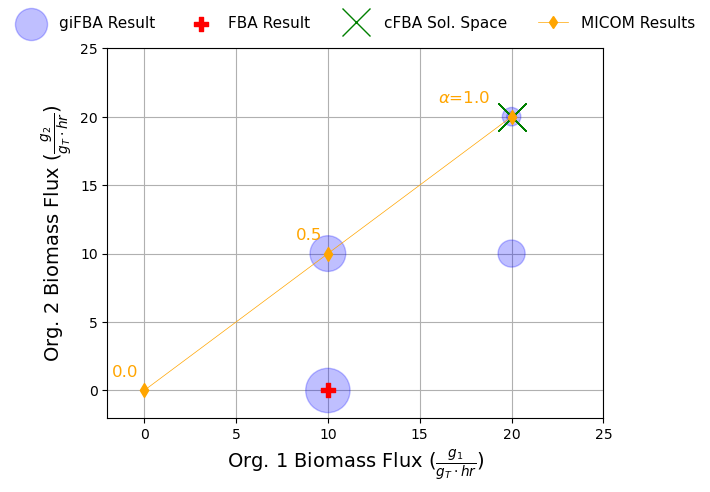

In [17]:
#plot model results
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# sizes for markers
fba_marker_size, cfba_marker_size, micom_marker_size = 100, 20, 50
gifba_marker_sizes = np.linspace(18, 4, community.iters)**2 * np.pi
micom_line_width = 0.5
colors = ["b", "r", "g", "orange"] # gifba, FBA, cFBA, MICOM


# plot giFBA results
bio1_gifba = community.org_fluxes.loc[0, :]["EX_Bio(e)"]
bio2_gifba = community.org_fluxes.loc[1, :]["EX_Bio(e)"]
plt.scatter(bio1_gifba, bio2_gifba, 
            color=colors[0],
            marker="o", 
            s=gifba_marker_sizes, 
            alpha=0.25,
            label="giFBA Result",
            zorder = 2)


# compared to cobrapy FBA
models, media = gifba.utils.load_simple_models(sim) # reload models (since giFBA changed them)
for model in models:
    for ex in model.exchanges:
        model.exchanges.get_by_id(ex.id).lower_bound = 0
for ex, flux in media.items():
    if ex in models[0].exchanges:
        models[0].exchanges.get_by_id(ex).lower_bound = flux
for ex, flux in media.items():
    if ex in models[1].exchanges:
        models[1].exchanges.get_by_id(ex).lower_bound = flux
bio1_fba = models[0].optimize().objective_value
bio2_fba = models[1].optimize().objective_value
plt.scatter(bio1_fba, bio2_fba, 
            color=colors[1], 
            marker="P", 
            s=fba_marker_size,
            label='FBA Result',
            zorder=3)


# compared to cFBA
cfba = pd.read_csv(f"Results/cFBA/cFBA_results_sim{sim}.csv", index_col=False)
plt.plot(cfba["First_Org_Flux"], cfba["Second_Org_Max_Flux"],
            color=colors[2], 
            marker="x", 
            ms=cfba_marker_size,  
            lw=0, 
            label='cFBA Sol. Space',
            zorder=3)


# compared to MICOM
micom = pd.read_csv("Results/micom_results.csv", index_col=0)
micom = micom.loc[sim]
plt.plot(micom["Org1_growth"], micom["Org2_growth"],
            color=colors[3], 
            lw=micom_line_width, 
            ms=micom_marker_size,
            zorder=3)

# label MICOM tradeoff points (only some)
micom_tradeoffs = [0.0, 0.5]
for alpha_tradeoff in micom_tradeoffs:
    posx = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org1_growth"].values[0]
    posy = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org2_growth"].values[0]
    plt.text(posx-1.75, posy+1, str(alpha_tradeoff),
            fontsize=12, zorder=3, color=colors[3])
    plt.scatter(posx, posy, 
                s=micom_marker_size, c=colors[3], marker="d", zorder=3)
alpha_tradeoff = 1.0
posx = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org1_growth"].values[0]
posy = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org2_growth"].values[0]
plt.text(posx-4, posy+1, r"$\alpha$=1.0",
        fontsize=12, zorder=3, color=colors[3])
plt.scatter(posx, posy, 
            s=micom_marker_size, c=colors[3], marker="d", zorder=3)

# create custom legend entry
micom_handle = plt.Line2D([0], [0], color=colors[3], lw=micom_line_width, marker="d", label='MICOM Results')
handles, labels = plt.gca().get_legend_handles_labels() # pull original legend
handles.append(micom_handle) # add new legend entry
labels.append("MICOM Results") # add new legend entry
plt.legend(handles=handles, labels=labels,
           fontsize=11, loc='upper center', bbox_to_anchor=(0.5, 1.125), ncol=4, frameon=False) 

# annotate
axis_lab_size = 14
plt.grid(zorder=0)
plt.xlabel(r"Org. 1 Biomass Flux ($\frac{g_1}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.ylabel(r"Org. 2 Biomass Flux ($\frac{g_2}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.xlim(-2, 25)
plt.ylim(-2, 25)

plt.savefig(f"Results/giFBA_Simple/gifba_sim{sim}.svg", bbox_inches='tight')

Notice, more iterations are required for convergence. This is evident in Simulation 3a, but made more clear in Simulation 3b. This is due to metabolites being added/returned to the media for cross-feeding after each iteration. Additionally, this emergent iteraction is not picked up by normal FBA.


## Simulation 3c: Cross-Feeding & Competition Between 2 Organisms
![Sim 3c Diagram](Model_Diagrams/sim3c_diagram.png)

In [18]:
import gifba

# load models and media:
sim = "3c"
models, media = gifba.utils.load_simple_models(sim) # sim. 3c

# initialize community
community = gifba.gifbaObject(models, media)
# run iterations
media_flux, org_flux = community.run_gifba(iters=5, method="pfba",   v=True)

Read LP format model from file /tmp/tmpqx2hoo82.lp
Reading time = 0.00 seconds
: 6 rows, 14 columns, 24 nonzeros
Read LP format model from file /tmp/tmpjlaom3xi.lp
Reading time = 0.00 seconds
: 6 rows, 16 columns, 26 nonzeros

Iteration: 0
EX_A(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 1
EX_A(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 2
EX_A(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 3
EX_A(e) over-consumed by factor of 2.000000000000 (rerun count: 0)
Converged at iteration 3
Model is periodic and average of the last 1 iterations will be used for flux calculations.


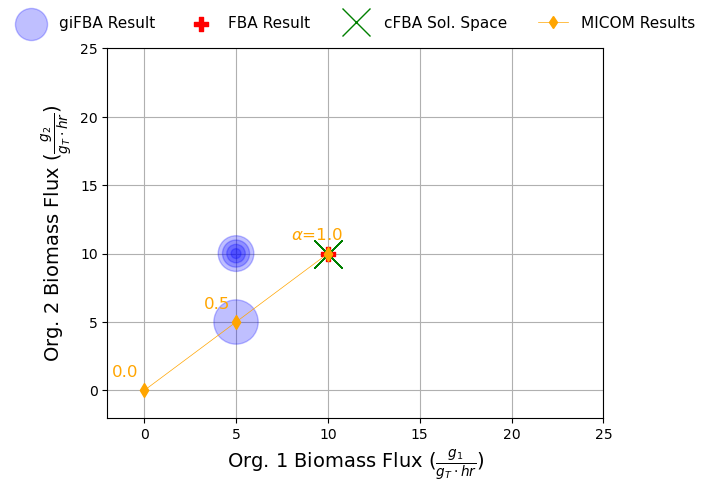

In [21]:
#plot model results
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# sizes for markers
fba_marker_size, cfba_marker_size, micom_marker_size = 100, 20, 50
gifba_marker_sizes = np.linspace(18, 4, community.iters)**2 * np.pi
micom_line_width = 0.5
colors = ["b", "r", "g", "orange"] # gifba, FBA, cFBA, MICOM


# plot giFBA results
bio1_gifba = community.org_fluxes.loc[0, :]["EX_Bio(e)"]
bio2_gifba = community.org_fluxes.loc[1, :]["EX_Bio(e)"]
plt.scatter(bio1_gifba, bio2_gifba, 
            color=colors[0],
            marker="o", 
            s=gifba_marker_sizes, 
            alpha=0.25,
            label="giFBA Result",
            zorder = 2)


# compared to cobrapy FBA
models, media = gifba.utils.load_simple_models(sim) # reload models (since giFBA changed them)
for model in models:
    for ex in model.exchanges:
        model.exchanges.get_by_id(ex.id).lower_bound = 0
for ex, flux in media.items():
    if ex in models[0].exchanges:
        models[0].exchanges.get_by_id(ex).lower_bound = flux
for ex, flux in media.items():
    if ex in models[1].exchanges:
        models[1].exchanges.get_by_id(ex).lower_bound = flux
bio1_fba = models[0].optimize().objective_value
bio2_fba = models[1].optimize().objective_value
plt.scatter(bio1_fba, bio2_fba, 
            color=colors[1], 
            marker="P", 
            s=fba_marker_size,
            label='FBA Result',
            zorder=3)


# compared to cFBA
cfba = pd.read_csv(f"Results/cFBA/cFBA_results_sim{sim}.csv", index_col=False)
plt.plot(cfba["First_Org_Flux"], cfba["Second_Org_Max_Flux"],
            color=colors[2], 
            marker="x", 
            ms=cfba_marker_size,  
            lw=0, 
            label='cFBA Sol. Space',
            zorder=3)


# compared to MICOM
micom = pd.read_csv("Results/micom_results.csv", index_col=0)
micom = micom.loc[sim]
plt.plot(micom["Org1_growth"], micom["Org2_growth"],
            color=colors[3], 
            lw=micom_line_width, 
            ms=micom_marker_size,
            zorder=3)

# label MICOM tradeoff points (only some)
micom_tradeoffs = [0.0, 0.5]
for alpha_tradeoff in micom_tradeoffs:
    posx = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org1_growth"].values[0]
    posy = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org2_growth"].values[0]
    plt.text(posx-1.75, posy+1, str(alpha_tradeoff),
            fontsize=12, zorder=3, color=colors[3])
    plt.scatter(posx, posy, 
                s=micom_marker_size, c=colors[3], marker="d", zorder=3)
alpha_tradeoff = 1.0
posx = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org1_growth"].values[0]
posy = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org2_growth"].values[0]
plt.text(posx-2, posy+1, r"$\alpha$=1.0",
        fontsize=12, zorder=3, color=colors[3])
plt.scatter(posx, posy, 
            s=micom_marker_size, c=colors[3], marker="d", zorder=3)

# create custom legend entry
micom_handle = plt.Line2D([0], [0], color=colors[3], lw=micom_line_width, marker="d", label='MICOM Results')
handles, labels = plt.gca().get_legend_handles_labels() # pull original legend
handles.append(micom_handle) # add new legend entry
labels.append("MICOM Results") # add new legend entry
plt.legend(handles=handles, labels=labels,
           fontsize=11, loc='upper center', bbox_to_anchor=(0.5, 1.125), ncol=4, frameon=False) 

# annotate
axis_lab_size = 14
plt.grid(zorder=0)
plt.xlabel(r"Org. 1 Biomass Flux ($\frac{g_1}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.ylabel(r"Org. 2 Biomass Flux ($\frac{g_2}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.xlim(-2, 25)
plt.ylim(-2, 25)

plt.savefig(f"Results/giFBA_Simple/gifba_sim{sim}.svg", bbox_inches='tight')

## Simulation 4: Superfluous Cross-Feeding
![Sim 4a Diagram](Model_Diagrams/sim4a_diagram.png)

In [24]:
import gifba

# load models and media:
sim = "4a"
models, media = gifba.utils.load_simple_models(sim) # sim. 4a

# initialize community
community = gifba.gifbaObject(models, media)
# run iterations
media_flux, org_flux = community.run_gifba(iters=5, method="pfba",   v=True)

Read LP format model from file /tmp/tmphpm6zp2x.lp
Reading time = 0.00 seconds
: 8 rows, 20 columns, 32 nonzeros
Read LP format model from file /tmp/tmpnsxoxha1.lp
Reading time = 0.00 seconds
: 6 rows, 16 columns, 26 nonzeros

Iteration: 0

Iteration: 1

Iteration: 2
Converged at iteration 2
Model is periodic and average of the last 1 iterations will be used for flux calculations.


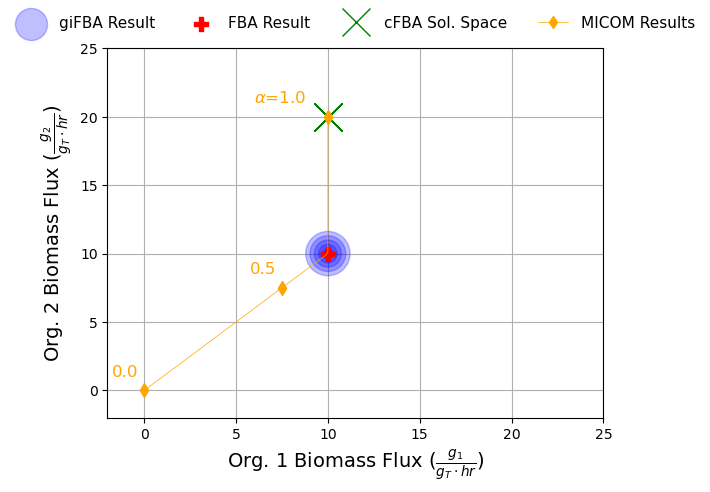

In [25]:
#plot model results
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# sizes for markers
fba_marker_size, cfba_marker_size, micom_marker_size = 100, 20, 50
gifba_marker_sizes = np.linspace(18, 4, community.iters)**2 * np.pi
micom_line_width = 0.5
colors = ["b", "r", "g", "orange"] # gifba, FBA, cFBA, MICOM


# plot giFBA results
bio1_gifba = community.org_fluxes.loc[0, :]["EX_Bio(e)"]
bio2_gifba = community.org_fluxes.loc[1, :]["EX_Bio(e)"]
plt.scatter(bio1_gifba, bio2_gifba, 
            color=colors[0],
            marker="o", 
            s=gifba_marker_sizes, 
            alpha=0.25,
            label="giFBA Result",
            zorder = 2)


# compared to cobrapy FBA
models, media = gifba.utils.load_simple_models(sim) # reload models (since giFBA changed them)
for model in models:
    for ex in model.exchanges:
        model.exchanges.get_by_id(ex.id).lower_bound = 0
for ex, flux in media.items():
    if ex in models[0].exchanges:
        models[0].exchanges.get_by_id(ex).lower_bound = flux
for ex, flux in media.items():
    if ex in models[1].exchanges:
        models[1].exchanges.get_by_id(ex).lower_bound = flux
bio1_fba = models[0].optimize().objective_value
bio2_fba = models[1].optimize().objective_value
plt.scatter(bio1_fba, bio2_fba, 
            color=colors[1], 
            marker="P", 
            s=fba_marker_size,
            label='FBA Result',
            zorder=3)


# compared to cFBA
cfba = pd.read_csv(f"Results/cFBA/cFBA_results_sim{sim}.csv", index_col=False)
plt.plot(cfba["First_Org_Flux"], cfba["Second_Org_Max_Flux"],
            color=colors[2], 
            marker="x", 
            ms=cfba_marker_size,  
            lw=0, 
            label='cFBA Sol. Space',
            zorder=3)


# compared to MICOM
micom = pd.read_csv("Results/micom_results.csv", index_col=0)
micom = micom.loc[sim]
plt.plot(micom["Org1_growth"], micom["Org2_growth"],
            color=colors[3], 
            lw=micom_line_width, 
            ms=micom_marker_size,
            zorder=3)

# label MICOM tradeoff points (only some)
micom_tradeoffs = [0.0, 0.5]
for alpha_tradeoff in micom_tradeoffs:
    posx = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org1_growth"].values[0]
    posy = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org2_growth"].values[0]
    plt.text(posx-1.75, posy+1, str(alpha_tradeoff),
            fontsize=12, zorder=3, color=colors[3])
    plt.scatter(posx, posy, 
                s=micom_marker_size, c=colors[3], marker="d", zorder=3)
alpha_tradeoff = 1.0
posx = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org1_growth"].values[0]
posy = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org2_growth"].values[0]
plt.text(posx-4, posy+1, r"$\alpha$=1.0",
        fontsize=12, zorder=3, color=colors[3])
plt.scatter(posx, posy, 
            s=micom_marker_size, c=colors[3], marker="d", zorder=3)

# create custom legend entry
micom_handle = plt.Line2D([0], [0], color=colors[3], lw=micom_line_width, marker="d", label='MICOM Results')
handles, labels = plt.gca().get_legend_handles_labels() # pull original legend
handles.append(micom_handle) # add new legend entry
labels.append("MICOM Results") # add new legend entry
plt.legend(handles=handles, labels=labels,
           fontsize=11, loc='upper center', bbox_to_anchor=(0.5, 1.125), ncol=4, frameon=False) 

# annotate
axis_lab_size = 14
plt.grid(zorder=0)
plt.xlabel(r"Org. 1 Biomass Flux ($\frac{g_1}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.ylabel(r"Org. 2 Biomass Flux ($\frac{g_2}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.xlim(-2, 25)
plt.ylim(-2, 25)

plt.savefig(f"Results/giFBA_Simple/gifba_sim{sim}.svg", bbox_inches='tight')

# SIm 5a Coupled-Growth

In [2]:
import gifba

# load models and media:
sim = "5a"
rel_abund = [0.2, 0.8]
models, media = gifba.utils.load_simple_models(sim) 
community = gifba.gifbaObject(models, media, rel_abund=rel_abund)
# run iterations
media_flux, org_flux = community.run_gifba(iters=5, method="pfba",   v=True)

Read LP format model from file /tmp/tmpxj10vw2z.lp
Reading time = 0.00 seconds
: 6 rows, 14 columns, 24 nonzeros
Read LP format model from file /tmp/tmp_u_kd3al.lp
Reading time = 0.00 seconds
: 6 rows, 14 columns, 24 nonzeros

Iteration: 0

Iteration: 1
EX_A(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 2
EX_A(e) over-consumed by factor of 1.200000000000 (rerun count: 0)

Iteration: 3
EX_A(e) over-consumed by factor of 1.800000000000 (rerun count: 0)

Iteration: 4
EX_A(e) over-consumed by factor of 1.200000000000 (rerun count: 0)
Converged at iteration 4
Model is periodic and average of the last 2 iterations will be used for flux calculations.


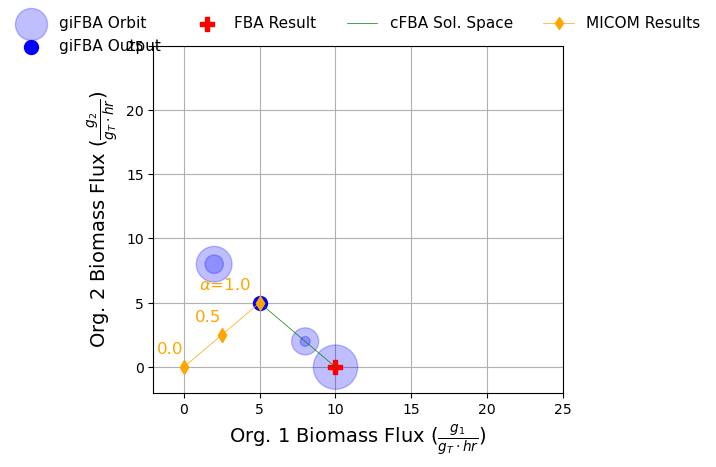

In [7]:
#plot model results
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# sizes for markers
fba_marker_size, cfba_marker_size, micom_marker_size = 100, 20, 50
gifba_marker_sizes = np.linspace(18, 4, community.iters)**2 * np.pi
micom_line_width = 0.5
colors = ["b", "r", "g", "orange"] # gifba, FBA, cFBA, MICOM


# plot giFBA results
bio1_gifba = community.org_fluxes.loc[0, :]["EX_Bio(e)"]
bio2_gifba = community.org_fluxes.loc[1, :]["EX_Bio(e)"]
plt.scatter(bio1_gifba, bio2_gifba, 
            color=colors[0],
            marker="o", 
            s=gifba_marker_sizes, 
            alpha=0.25,
            label="giFBA Orbit",
            zorder = 2)
plt.scatter(org_flux.loc[0]["EX_Bio(e)"], org_flux.loc[1]["EX_Bio(e)"],
            color=colors[0],
            marker="o", 
            s=gifba_marker_sizes[-1]*2, 
            label="giFBA Output",
            zorder = 3)


# compared to cobrapy FBA
models, media = gifba.utils.load_simple_models(sim) # reload models (since giFBA changed them)
for model in models:
    for ex in model.exchanges:
        model.exchanges.get_by_id(ex.id).lower_bound = 0
for ex, flux in media.items():
    if ex in models[0].exchanges:
        models[0].exchanges.get_by_id(ex).lower_bound = flux
for ex, flux in media.items():
    if ex in models[1].exchanges:
        models[1].exchanges.get_by_id(ex).lower_bound = flux
bio1_fba = models[0].optimize().objective_value
bio2_fba = models[1].optimize().objective_value
plt.scatter(bio1_fba, bio2_fba, 
            color=colors[1], 
            marker="P", 
            s=fba_marker_size,
            label='FBA Result',
            zorder=3)


# compared to cFBA
cfba = pd.read_csv(f"Results/cFBA/cFBA_results_sim{sim}.csv", index_col=False)
plt.plot(cfba["First_Org_Flux"], cfba["Second_Org_Max_Flux"],
            color=colors[2], 
            lw=micom_line_width, 
            label='cFBA Sol. Space',
            zorder=3)


# compared to MICOM
micom = pd.read_csv("Results/micom_results.csv", index_col=0)
micom = micom.loc[sim]
plt.plot(micom["Org1_growth"], micom["Org2_growth"],
            color=colors[3], 
            lw=micom_line_width, 
            ms=micom_marker_size,
            zorder=3)

# label MICOM tradeoff points (only some)
micom_tradeoffs = [0.0, 0.5]
for alpha_tradeoff in micom_tradeoffs:
    posx = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org1_growth"].values[0]
    posy = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org2_growth"].values[0]
    plt.text(posx-1.75, posy+1, str(alpha_tradeoff),
            fontsize=12, zorder=3, color=colors[3])
    plt.scatter(posx, posy, 
                s=micom_marker_size, c=colors[3], marker="d", zorder=3)
alpha_tradeoff = 1.0
posx = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org1_growth"].values[0]
posy = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org2_growth"].values[0]
plt.text(posx-4, posy+1, r"$\alpha$=1.0",
        fontsize=12, zorder=3, color=colors[3])
plt.scatter(posx, posy, 
            s=micom_marker_size, c=colors[3], marker="d", zorder=3)

# create custom legend entry
micom_handle = plt.Line2D([0], [0], color=colors[3], lw=micom_line_width, marker="d", label='MICOM Results')
handles, labels = plt.gca().get_legend_handles_labels() # pull original legend
handles.append(micom_handle) # add new legend entry
labels.append("MICOM Results") # add new legend entry
plt.legend(handles=handles, labels=labels,
           fontsize=11, loc='upper center', bbox_to_anchor=(0.5, 1.125), ncol=4, frameon=False) 

# annotate
axis_lab_size = 14
plt.grid(zorder=0)
plt.xlabel(r"Org. 1 Biomass Flux ($\frac{g_1}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.ylabel(r"Org. 2 Biomass Flux ($\frac{g_2}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.xlim(-2, 25)
plt.ylim(-2, 25)
plt.tight_layout()

plt.savefig(f"Results/giFBA_Simple/gifba_sim{sim}.svg", bbox_inches='tight')

# Real-Life Examples
The following examples utilize AGORA2 models to understand how growth compares. These examples will also show how to use the summary class/method for analyzing the community. 

## Example 1: Pairwise Interactions
- Escherichia coli str. K12 substr. MG1655 & Bacterioides thetaiotaomicron 3731
    - [Download Escherichia_coli_str_K_12_substr_MG1655.mat Here](https://www.vmh.life/files/reconstructions/AGORA2/version2.01/mat_files/individual_reconstructions/Escherichia_coli_str_K_12_substr_MG1655.mat)
    - [Download Bacteroides_thetaiotaomicron_3731.mat Here](https://www.vmh.life/files/reconstructions/AGORA2/version2.01/mat_files/individual_reconstructions/Bacteroides_thetaiotaomicron_3731.mat)

In [26]:
import cobra as cb
import gifba

EC_path = "AGORA2_Models/Escherichia_coli_str_K_12_substr_MG1655.mat"
EC = cb.io.load_matlab_model(EC_path)

BT_path = "AGORA2_Models/Bacteroides_thetaiotaomicron_3731.mat"
BT = cb.io.load_matlab_model(BT_path)

#example glucose minimal media
min_med_ids_ex = ['EX_glc_D(e)','EX_so4(e)','EX_nh4(e)','EX_pi(e)','EX_cys_L(e)',
            'EX_mn2(e)','EX_cl(e)','EX_ca2(e)','EX_mg2(e)','EX_cu2(e)',
            'EX_cobalt2(e)','EX_fe2(e)','EX_fe3(e)','EX_zn2(e)','EX_k(e)']
# Define medium uptake flux bounds
min_med_fluxes_ex = [-10,-100,-100,-100,-100,
                    -100,-100,-100,-100,-100,-100,-100,-100,-100,-100]
media = dict(zip(min_med_ids_ex, min_med_fluxes_ex))

# initialize community
community = gifba.gifbaObject([EC, BT], media, rel_abund=[0.5, 0.5])
# run iterations
media_flux, org_flux = community.run_gifba(iters=10, method="pfba", v=True, threshold=0.001) 
# visual inspection of community.org_fluxes shows model almost converges by iter 3
# threshold of 0.001 means that if the change in biomass flux is less than 0.001 
# between iterations, giFBA will stop iterating (i.e. it has converged) to increase efficiency

No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e, p
No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e, p


Read LP format model from file /tmp/tmpdxsox8rx.lp
Reading time = 0.01 seconds
: 2630 rows, 6554 columns, 22274 nonzeros
Read LP format model from file /tmp/tmpdm1mnz5w.lp
Reading time = 0.00 seconds
: 1318 rows, 3010 columns, 11452 nonzeros

Iteration: 0
EX_glc_D(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 1
EX_glc_D(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 2
EX_glc_D(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 3
EX_glc_D(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 4
EX_glc_D(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 5
EX_glc_D(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 6
EX_glc_D(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 7
EX_glc_D(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 8
EX_glc_D(e) over-consumed by factor of 2.000000000000 (rerun cou

EC FBA optimal: 0.29198339258999995
BT FBA optimal: 0.3841775989337022


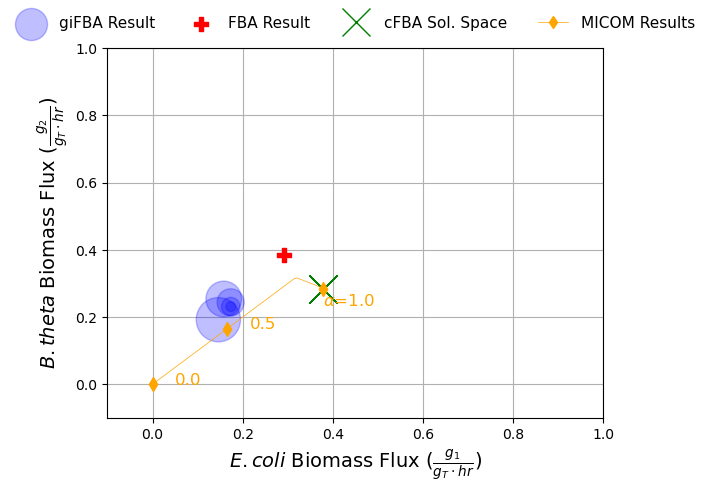

In [27]:
#plot model results
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# sizes for markers
fba_marker_size, cfba_marker_size, micom_marker_size = 100, 20, 50
gifba_marker_sizes = np.linspace(18, 4, 5)**2 * np.pi
micom_line_width = 0.5
colors = ["b", "r", "g", "orange"] # gifba, FBA, cFBA, MICOM


# plot giFBA results
EC_gifba = community.org_fluxes.loc[0, :]["biomass525"].to_numpy()[:5]
BT_gifba = community.org_fluxes.loc[1, :]["bio1"].to_numpy()[:5]
plt.scatter(EC_gifba, BT_gifba, 
			color=colors[0],
			marker="o", 
			s=gifba_marker_sizes, 
			alpha=0.25,
			label="giFBA Result",
			zorder = 2)

# compared to cobrapy FBA
for model in [EC, BT]:
    for ex in model.exchanges:
        model.exchanges.get_by_id(ex.id).lower_bound = 0
        model.exchanges.get_by_id(ex.id).upper_bound = 1000
for ex, flux in media.items():
    if ex in EC.exchanges:
        EC.exchanges.get_by_id(ex).lower_bound = flux
EC_optimal = EC.optimize().objective_value

for ex, flux in media.items():
    if ex in BT.exchanges:
        BT.exchanges.get_by_id(ex).lower_bound = flux
BT_optimal = BT.optimize().objective_value

print("EC FBA optimal:", EC_optimal)
print("BT FBA optimal:", BT_optimal)

plt.scatter(EC_optimal, BT_optimal, 
            color=colors[1], 
            marker="P", 
            s=fba_marker_size,
            label='FBA Result',
            zorder=3)

# compared to cFBA
cfba = pd.read_csv(f"Results/cFBA/cFBA_results_EC_BT.csv", index_col=False)
plt.plot(cfba["First_Org_Flux"], cfba["Second_Org_Max_Flux"],
            color=colors[2], 
            marker="x", 
            ms=cfba_marker_size,  
            lw=0, 
            label='cFBA Sol. Space',
            zorder=3)

# compared to MICOM
sim = "EC_BT"
micom = pd.read_csv("Results/micom_results_real.csv", index_col=0)
micom = micom.loc[sim]
plt.plot(micom["Org1_growth"], micom["Org2_growth"],
            color=colors[3], 
            lw=micom_line_width, 
            ms=micom_marker_size,
            zorder=3)

# label MICOM tradeoff points (only some)
micom_tradeoffs = [0.0, 0.5]
for alpha_tradeoff in micom_tradeoffs:
    posx = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org1_growth"].values[0]
    posy = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org2_growth"].values[0]
    plt.text(posx+0.05, posy, str(alpha_tradeoff),
            fontsize=12, zorder=3, color=colors[3])
    plt.scatter(posx, posy, 
                s=micom_marker_size, c=colors[3], marker="d", zorder=3)
alpha_tradeoff = 1.0
posx = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org1_growth"].values[0]
posy = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org2_growth"].values[0]
plt.text(posx, posy-0.05, r"$\alpha$=1.0",
        fontsize=12, zorder=3, color=colors[3])
plt.scatter(posx, posy, 
            s=micom_marker_size, c=colors[3], marker="d", zorder=3)

# create custom legend entry
micom_handle = plt.Line2D([0], [0], color=colors[3], lw=micom_line_width, marker="d", label='MICOM Results')
handles, labels = plt.gca().get_legend_handles_labels() # pull original legend
handles.append(micom_handle) # add new legend entry
labels.append("MICOM Results") # add new legend entry
plt.legend(handles=handles, labels=labels,
           fontsize=11, loc='upper center', bbox_to_anchor=(0.5, 1.125), ncol=4, frameon=False) 

# annotate
axis_lab_size = 14
plt.grid(zorder=0)
plt.xlabel(r"$\it{E. coli}$ Biomass Flux ($\frac{g_1}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.ylabel(r"$\it{B. theta}$ Biomass Flux ($\frac{g_2}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.xlim(-0.1, 1)
plt.ylim(-0.1, 1)

plt.savefig(f"Results/giFBA_AGORA/gifba_ECBT.svg", bbox_inches='tight')

### Community Summary

The Summary Class, made with Community.summary(...) generates a summary table output similar to cobra. The community summary will generate one Uptake/Secretion Subsection for the Community together, then one for each model in the community.

Community: Class representation for an iteration of an iiFBA community

`class iifba.summary.Summary(community:[iifba.Community], iter_shown: Optional[int, None] = None, element: Optional[str] = "C")`<br>
> Class representation for an iteration of an iiFBA community<br><br>

> **Parameters** <br>
> - **Community**(*iifba.Community*) - iifba Community object. If iiFBA has not been run, summary will be generated, but iifba.Community attributes are initialized with zeros, so no significant data will be shown until running `community.iifba()`
> - **iter_shown**(*int, None, optional*) - Iteration to summarize. Defaults to None. If None, the last iteration will be summarized and displayed.
> - **element**(*str,  optional*) - Element to evaluate with summary. Modified from cobrapy summary, will display the flux and percents of the given element. Default element is 'C' for Carbon.

> **Attributes**<br>
> - will go back and edit this
> -
>

> **Methods**<br>
> - will go back and edit this
> -


In [55]:
# generate community summary
summary = community.summarize()

# save to a cytoscape format
edge, node = summary.to_cytoscape()
edge.to_csv("Results/giFBA_AGORA/EC_BT_edges.csv")
node.to_csv("Results/giFBA_AGORA/EC_BT_nodes.csv")

# display summary
summary

Metabolite,Exchange,Flux,C-Number,C-Flux
so4[e],EX_so4(e),0.051379,0,0.00%
mn2[e],EX_mn2(e),0.003189,0,0.00%
k[e],EX_k(e),0.003189,0,0.00%
cl[e],EX_cl(e),0.003189,0,0.00%
fe3[e],EX_fe3(e),0.003189,0,0.00%
fe2[e],EX_fe2(e),0.006854,0,0.00%
cobalt2[e],EX_cobalt2(e),0.003189,0,0.00%
zn2[e],EX_zn2(e),0.003189,0,0.00%
ca2[e],EX_ca2(e),0.003189,0,0.00%
pi[e],EX_pi(e),0.381015,0,0.00%


## Another Real Model (B. infantis and A. hallii)


In [28]:
import cobra as cb
import gifba
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BI = cb.io.load_matlab_model('AGORA2_Models/Bifidobacterium_longum_infantis_ATCC_15697.mat')
AH = cb.io.load_matlab_model('AGORA2_Models/Eubacterium_hallii_DSM_3353.mat')

models = [BI, AH]

# AGORA Format
media = {
	'EX_o2(e)': 0, #aerobic/anaerobic
	'EX_h2o(e)': -1000,
	'EX_pi(e)': -1000,
	'EX_fe2(e)': -1000,
	'EX_fe3(e)': -1000,
	'EX_zn2(e)': -1000,
	'EX_so4(e)': -1000,
	'EX_cu2(e)': -1000,
	'EX_k(e)': -1000,
	'EX_mg2(e)': -1000,
	'EX_mn2(e)': -1000,
	'EX_cd2(e)': -1000,
	'EX_cl(e)': -1000,
	'EX_ca2(e)': -1000,
	'EX_cobalt2(e)': -1000,
	'EX_glc_D(e)': -10,
	'EX_nh4(e)': -20,

	'EX_ribflv(e)': -1000,
	'EX_pnto_R(e)': -1000,
	'EX_nac(e)': -1000,
	'EX_his_L(e)': -1000,
	'EX_asn_L(e)': -1000,
	'EX_glycys(e)': -1000,

	'EX_lys_L(e)': -1000,
	'EX_ala_L(e)': -1000,
	'EX_met_L(e)': -1000,
	'EX_leu_L(e)': -1000,
	'EX_hxan(e)': -1000,    
    'EX_glyglu(e)': -1000
	# 'EX_ser_L(e)': -1 #-1
}

# initialize community
community = gifba.gifbaObject(models, media, rel_abund="equal")

# run iterations
media_flux, org_flux = community.run_gifba(iters=5, method="pfba", threshold=True, v=True)

No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e
No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e


Read LP format model from file /tmp/tmp85m5cceo.lp
Reading time = 0.00 seconds
: 932 rows, 2064 columns, 8440 nonzeros
Read LP format model from file /tmp/tmp8g20aov4.lp
Reading time = 0.00 seconds
: 980 rows, 2102 columns, 8980 nonzeros

Iteration: 0
EX_glc_D(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 1
EX_glc_D(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 2
EX_glc_D(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 3
EX_glc_D(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 4
EX_glc_D(e) over-consumed by factor of 2.000000000000 (rerun count: 0)
Converged at iteration 4
Model is periodic and average of the last 1 iterations will be used for flux calculations.


BI FBA optimal: 0.13353637458967868
AH FBA optimal: 0.4147595691023793


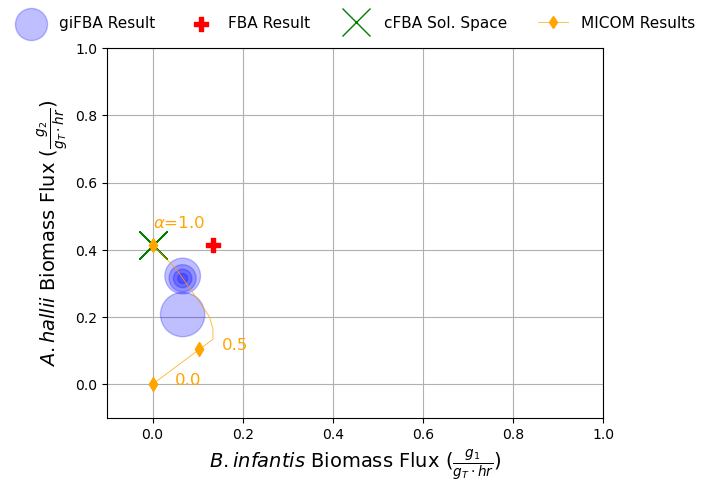

In [29]:
#plot model results
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# sizes for markers
fba_marker_size, cfba_marker_size, micom_marker_size = 100, 20, 50
gifba_marker_sizes = np.linspace(18, 4, community.iters)**2 * np.pi
micom_line_width = 0.5
colors = ["b", "r", "g", "orange"] # gifba, FBA, cFBA, MICOM


# plot giFBA results
BI_gifba = community.org_fluxes.loc[0, :]["EX_biomass(e)"]
AH_gifba = community.org_fluxes.loc[1, :]["EX_biomass(e)"]
plt.scatter(BI_gifba, AH_gifba, 
			color=colors[0],
			marker="o", 
			s=gifba_marker_sizes, 
			alpha=0.25,
			label="giFBA Result",
			zorder = 2)

# compared to cobrapy FBA
for model in models:
    for ex in model.exchanges:
        model.exchanges.get_by_id(ex.id).lower_bound = 0
        model.exchanges.get_by_id(ex.id).upper_bound = 1000
for ex, flux in media.items():
    if ex in BI.exchanges:
        BI.exchanges.get_by_id(ex).lower_bound = flux
BI_optimal = BI.optimize().objective_value

for ex, flux in media.items():
    if ex in AH.exchanges:
        AH.exchanges.get_by_id(ex).lower_bound = flux
AH_optimal = AH.optimize().objective_value

print("BI FBA optimal:", BI_optimal)
print("AH FBA optimal:", AH_optimal)

plt.scatter(BI_optimal, AH_optimal, 
            color=colors[1], 
            marker="P", 
            s=fba_marker_size,
            label='FBA Result',
            zorder=3)

# compared to cFBA
cfba = pd.read_csv(f"Results/cFBA/cFBA_results_BI_AH.csv", index_col=False)
plt.plot(cfba["First_Org_Flux"], cfba["Second_Org_Max_Flux"],
            color=colors[2], 
            marker="x", 
            ms=cfba_marker_size,  
            lw=0, 
            label='cFBA Sol. Space',
            zorder=3)

# compared to MICOM
sim = "BI_AH"
micom = pd.read_csv("Results/micom_results_real.csv", index_col=0)
micom = micom.loc[sim]
plt.plot(micom["Org1_growth"], micom["Org2_growth"],
            color=colors[3], 
            lw=micom_line_width, 
            ms=micom_marker_size,
            zorder=3)

# label MICOM tradeoff points (only some)
micom_tradeoffs = [0.0, 0.5]
for alpha_tradeoff in micom_tradeoffs:
    posx = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org1_growth"].values[0]
    posy = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org2_growth"].values[0]
    plt.text(posx+0.05, posy, str(alpha_tradeoff),
            fontsize=12, zorder=3, color=colors[3])
    plt.scatter(posx, posy, 
                s=micom_marker_size, c=colors[3], marker="d", zorder=3)
alpha_tradeoff = 1.0
posx = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org1_growth"].values[0]
posy = micom[micom["tradeoff"] == alpha_tradeoff].reset_index()["Org2_growth"].values[0]
plt.text(posx, posy+0.05, r"$\alpha$=1.0",
        fontsize=12, zorder=3, color=colors[3])
plt.scatter(posx, posy, 
            s=micom_marker_size, c=colors[3], marker="d", zorder=3)

# create custom legend entry
micom_handle = plt.Line2D([0], [0], color=colors[3], lw=micom_line_width, marker="d", label='MICOM Results')
handles, labels = plt.gca().get_legend_handles_labels() # pull original legend
handles.append(micom_handle) # add new legend entry
labels.append("MICOM Results") # add new legend entry
plt.legend(handles=handles, labels=labels,
           fontsize=11, loc='upper center', bbox_to_anchor=(0.5, 1.125), ncol=4, frameon=False) 

# annotate
axis_lab_size = 14
plt.grid(zorder=0)
plt.xlabel(r"$\it{B. infantis}$ Biomass Flux ($\frac{g_1}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.ylabel(r"$\it{A. hallii}$ Biomass Flux ($\frac{g_2}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.xlim(-0.1, 1)
plt.ylim(-0.1, 1)

plt.savefig(f"Results/giFBA_AGORA/gifba_BIAH.svg", bbox_inches='tight')

## Example 2: Larger Community Interactions
The following community comes from [Negative interactions determine Clostridioides difficile growth in synthetic human gut communities](https://www.embopress.org/doi/full/10.15252/msb.202110355#msb202110355-sup-0006)
Figure 3B Displays CommI has the lowest C. difficile abundance and with the lowest richness. This is a great example for demonstrating how iiFBA can show community interactions on communities with more than 2 organisms. CommI composition is detailed in the Data availability section.

To simplify computation and download requirements, the Virtual Metabolic Human ([VMH](vmh.life)) European Diet will be used. The following are models for download:
| Name | Details | Link|
|:----:|:-------:|:---:|
|Average European Diet| Commonly Used Diet from VMH | [Download Avg. EU Diet here](https://vmh.life/#diet/EU%20average)|
|*Clostridium difficile* (*C. diff* or CD)| *C. diff* ribotype 027 is known as hypervirulent | [Download *C. diff* Model Here](https://www.vmh.life/files/reconstructions/AGORA2/version2.01/mat_files/individual_reconstructions/Clostridium_difficile_R20291.mat)|
|*Clostridium hiranonis* (*C. hiranonis* or CD)| *C. hiranonis* is a *C. diff* competitor | [Download *C. hiranonis* Model Here](https://www.vmh.life/files/reconstructions/AGORA2/version2.01/mat_files/individual_reconstructions/Clostridium_hiranonis_TO_931_DSM_13275.mat)|
|*Eggerthela lenta* (*E. lenta* or EL)| *E. lenta* is known to promote growth of other bacteria | [Download *E. lenta* Model Here](https://www.vmh.life/files/reconstructions/AGORA2/version2.01/mat_files/individual_reconstructions/Eggerthella_lenta_DSM_11767.mat)|
|*Bacteroides thetaiotaomicron* (*B. theta* or BT) | Known to compete with *C. diff*. Same model as Above Community|[Download *B. theta* Model Here](https://www.vmh.life/files/reconstructions/AGORA2/version2.01/mat_files/individual_reconstructions/Bacteroides_thetaiotaomicron_3731.mat)|


In [1]:
import gifba
import cobra as cb
import pandas as pd

# load models
CD_path = "AGORA2_Models/Clostridium_difficile_R20291.mat"
CD = cb.io.load_matlab_model(CD_path)

CH_path = "AGORA2_Models/Clostridium_hiranonis_TO_931_DSM_13275.mat"
CH = cb.io.load_matlab_model(CH_path)

BT_path = "AGORA2_Models/Bacteroides_thetaiotaomicron_3731.mat"
BT = cb.io.load_matlab_model(BT_path)

EL_path = "AGORA2_Models/Eggerthella_lenta_DSM_11767.mat"
EL = cb.io.load_matlab_model(EL_path)

euro_media = "AGORA2_Models/euro_diet.tsv"
euro_media = pd.read_csv(euro_media, sep="\t", header=0, index_col=0).to_dict()
euro_media = euro_media["Flux Value"]
euro_media = {ex.replace("[e]", "(e)"): -flux for ex, flux in euro_media.items()}

# # initialize community
models = [CD, CH, BT, EL]
community = gifba.gifbaObject(models, [euro_media, 0.1], # minimal media
                            rel_abund=[0.1, 0.3, 0.3, 0.3]) # unequal similar to Hromada et al.

for ex, flux in community.media.items():
    if ex not in euro_media:
        print(ex, flux)

euro_media["EX_cobalt2(e)"] = -1000 #cobalt
euro_media["EX_so4(e)"] = -1000 # sulfate
euro_media["EX_adn(e)"] = -1000 #Adenosine
euro_media["EX_cytd(e)"] = -1000 # cytidine
euro_media["EX_thymd(e)"] = -1000 # thymidine
euro_media["EX_hspg(e)"] = -1 # Heparan Sulfate Proteoglycan
euro_media["EX_26dap_M(e)"] = -10 # Meso-2,6-Diaminoheptanedioate
euro_media["EX_cgly(e)"] = -1000 # Cysteinylglycine - dipep
euro_media["EX_glyasn(e)"] = -1000 # Glycylasparagine - dipep
euro_media["EX_nmn(e)"] = -1000 # Nicotinamide ribotide
euro_media["EX_pheme(e)"] = -1000 #p heme
euro_media["EX_sheme(e)"] = -1000 # s heme
euro_media["EX_spmd(e)"] = -1000 # spermidine

community = gifba.gifbaObject(models, [euro_media, 0.1], # minimal media
                            rel_abund=[0.1, 0.3, 0.3, 0.3]) # unequal similar to Hromada et al.
# # run iterations
media_flux, org_flux = community.run_gifba(iters=5, method="pfba", threshold=True, v=True) # early stopping simply checks if there are ANY changes in the media and quits if not




Set parameter Username
Set parameter LicenseID to value 2773321
Academic license - for non-commercial use only - expires 2027-02-01


No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e
No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e
No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e, p
No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e


Read LP format model from file /tmp/tmpez8x_2ln.lp
Reading time = 0.00 seconds
: 1194 rows, 2808 columns, 11912 nonzeros
Read LP format model from file /tmp/tmpzf9edqhh.lp
Reading time = 0.00 seconds
: 953 rows, 1980 columns, 8492 nonzeros
Read LP format model from file /tmp/tmpb5gu241n.lp
Reading time = 0.00 seconds
: 1318 rows, 3010 columns, 11452 nonzeros
Read LP format model from file /tmp/tmpxzalnznt.lp
Reading time = 0.00 seconds
: 1184 rows, 2326 columns, 10388 nonzeros
EX_cobalt2(e) -0.0007939700000179073
EX_so4(e) -0.00079397
EX_adn(e) -0.04417410000007749
EX_cytd(e) -0.02837029998863727
EX_thymd(e) -0.0011746999999786567
EX_hspg(e) -6.616416666638082e-05
EX_26dap_M(e) -0.03104510000002847
EX_cgly(e) -0.00730505000001358
EX_glyasn(e) -0.593552355500151
EX_nmn(e) -0.0006193000001530891
EX_pheme(e) -0.0003096499999628577
EX_sheme(e) -0.0003096499999628577
EX_spmd(e) -0.0003096499999628577
Read LP format model from file /tmp/tmp59n9sxt3.lp
Reading time = 0.00 seconds
: 1194 rows,

/home/rseag/UVM/M3_Lab/giFBA/package/gifba/utils.py:90: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  min_medium = pd.concat(min_medium, axis=1).fillna(0)



Iteration: 0
EX_ribflv(e) over-consumed by factor of 2.167685009547 (rerun count: 0)
EX_pydx(e) over-consumed by factor of 1.359053166943 (rerun count: 2)
EX_ser_L(e) over-consumed by factor of 1.102758234284 (rerun count: 4)
EX_cu2(e) over-consumed by factor of 1.098671731733 (rerun count: 6)
EX_his_L(e) over-consumed by factor of 1.002489312999 (rerun count: 8)

Iteration: 1
EX_ribflv(e) over-consumed by factor of 2.167685009547 (rerun count: 0)
EX_pydx(e) over-consumed by factor of 1.359053166943 (rerun count: 2)
EX_h(e) over-consumed by factor of 1.150532222356 (rerun count: 4)
EX_cu2(e) over-consumed by factor of 1.098671731733 (rerun count: 6)
EX_his_L(e) over-consumed by factor of 1.002489312999 (rerun count: 8)

Iteration: 2
EX_ribflv(e) over-consumed by factor of 2.167685009547 (rerun count: 0)
EX_pydx(e) over-consumed by factor of 1.359053166943 (rerun count: 2)
EX_cu2(e) over-consumed by factor of 1.098671731733 (rerun count: 4)
EX_his_L(e) over-consumed by factor of 1.0024

In [30]:
#plot model results
import gifba
import matplotlib.pyplot as plt
import numpy as np

# sizes for markers
fba_marker_size, cfba_marker_size, micom_marker_size = 100, 20, 50
gifba_marker_sizes = np.linspace(18, 4, community.iters)**2 * np.pi
micom_line_width = 0.5
colors = ["b", "r", "g", "orange"] # gifba, FBA, cFBA, MICOM

# extract cumulative growth for each organism
CD_gifba = community.org_fluxes.loc[0, :]["EX_biomass(e)"]
CH_gifba = community.org_fluxes.loc[1, :]["EX_biomass(e)"]
BT_gifba = community.org_fluxes.loc[2, :]["EX_biomass(e)"]
EL_gifba = community.org_fluxes.loc[3, :]["EX_biomass(e)"]

# plot giFBA results for each org
fig, ax = plt.subplots(2,2, sharey=True, figsize=(10,8))
ax[0, 0].plot(CD_gifba, lw=0, marker="o", color="b", label="giFBA Result", zorder=3)
ax[0, 1].plot(CH_gifba, lw=0, marker="o", color="b", label="giFBA Result", zorder=3)
ax[1, 0].plot(BT_gifba, lw=0, marker="o", color="b", label="giFBA Result", zorder=3)
ax[1, 1].plot(EL_gifba, lw=0, marker="o", color="b", label="giFBA Result", zorder=3)

# compared to cobrapy FBA
# reset model bounds, set media, simulate
# CD
media = community.media
with CD as model:
    for ex in model.exchanges:
        model.exchanges.get_by_id(ex.id).lower_bound = 0
    for ex, flux in media.items():
        if ex in model.exchanges:
            model.exchanges.get_by_id(ex).lower_bound = flux
    CD_fba = model.optimize().objective_value
# fba for CH
with CH as model:
    for ex in model.exchanges:
        model.exchanges.get_by_id(ex.id).lower_bound = 0
    for ex, flux in media.items():
        if ex in model.exchanges:
            model.exchanges.get_by_id(ex).lower_bound = flux
    CH_fba = model.optimize().objective_value
# fba for BT
with BT as model:
    for ex in model.exchanges:
        model.exchanges.get_by_id(ex.id).lower_bound = 0
    for ex, flux in media.items():
        if ex in model.exchanges:
            model.exchanges.get_by_id(ex).lower_bound = flux
    BT_fba = model.optimize().objective_value
# fba for EL
with EL as model:
    for ex in model.exchanges:
        model.exchanges.get_by_id(ex.id).lower_bound = 0
    for ex, flux in media.items():
        if ex in model.exchanges:
            model.exchanges.get_by_id(ex).lower_bound = flux
    EL_fba = model.optimize().objective_value

print(CD_fba, CH_fba, BT_fba, EL_fba)

ax[0, 0].plot([CD_fba]*community.iters, color='r', label='FBA Result', zorder=2)
ax[0, 1].plot([CH_fba]*community.iters, color='r', label='FBA Result', zorder=2)
ax[1, 0].plot([BT_fba]*community.iters, color='r', label='FBA Result', zorder=2)
ax[1, 1].plot([EL_fba]*community.iters, color='r', label='FBA Result', zorder=2)

sim = "Cdiff_Community"
micom = pd.read_csv("Results/micom_results_real.csv", index_col=0)
micom = micom.loc[sim]
ax_micom = np.array([ax[0,0].twiny(), ax[0,1].twiny(), ax[1,0].twiny(), ax[1,1].twiny()])
for org_idx in range(4):
    ax_micom[org_idx].plot(micom["tradeoff"], micom[f"Org{org_idx+1}_growth"], 0, community.iters-1, color=colors[3], zorder=3)
    ax_micom[org_idx].set_xlabel(r"MICOM $\alpha$ Parameter", color=colors[3])
    ax_micom[org_idx].tick_params(axis="x", colors=colors[3])

cfba = pd.read_csv(f"Results/cFBA/cFBA_results_{sim}.csv", index_col=False)
cfba = cfba[["First_Org_Flux", "Second_Org_Max_Flux", "3rd_Org_Max_Flux", "4th_Org_Max_Flux"]].values



ax[0, 0].grid()
ax[0, 1].grid()
ax[1, 0].grid()
ax[1, 1].grid()

# annotate
axis_lab_size = 14
ax[0,0].set_xlabel("Iteration", fontsize=axis_lab_size)
ax[0,1].set_xlabel("Iteration", fontsize=axis_lab_size)
ax[1,0].set_xlabel("Iteration", fontsize=axis_lab_size)
ax[1,1].set_xlabel("Iteration", fontsize=axis_lab_size)
ax[0,0].set_ylabel("C. difficile", fontsize=axis_lab_size)
ax[0,1].set_ylabel("C. hiranonis", fontsize=axis_lab_size)
ax[1,0].set_ylabel("B. thetaiotaomicron\n" + r"Biomass Flux ($\frac{g_i}{g_T \cdot hr}$)", fontsize=axis_lab_size)
ax[1,1].set_ylabel("E. lenta", fontsize=axis_lab_size)

# legend
handles = [plt.Line2D([0], [0], color="b", lw=0, marker="o", label='giFBA Result'),
           plt.Line2D([0], [0], color="r", lw=1, label='FBA Result')]
fig.legend(handles=handles, labels=["giFBA Result", "FBA Result"],
           fontsize=11, loc='upper center', bbox_to_anchor=(0.5, 1.125), ncol=2, frameon=False)
plt.tight_layout()

plt.savefig("Results/giFBA_AGORA/gifba_4bactcomm.svg", bbox_inches='tight')

KeyError: 2

                 tradeoff   Org1_growth  Org2_growth  Org3_growth  Org4_growth
simulation                                                                    
Cdiff_Community      1.00  2.696414e-13     0.411102     4.049882     0.099999
Cdiff_Community      0.75  3.681647e-02     0.373671     2.910249     0.100000
Cdiff_Community      0.50  3.871254e-02     0.371743     1.770035     0.100000
Cdiff_Community      0.25  4.060861e-02     0.369816     0.629821     0.100000
Model
0    0.259170
1    0.147607
2    4.049880
3    0.100000
Name: EX_biomass(e), dtype: float64
[0.4043551415401842, 0.23646081183750992, 4.493235781573284, 0.10000000000024321]
                 tradeoff   Org1_growth  Org2_growth  Org3_growth  Org4_growth
simulation                                                                    
Cdiff_Community      1.00  2.696414e-13     0.411102     4.049882     0.099999
Cdiff_Community      0.75  3.681647e-02     0.373671     2.910249     0.100000
Cdiff_Community      0.50  3.8

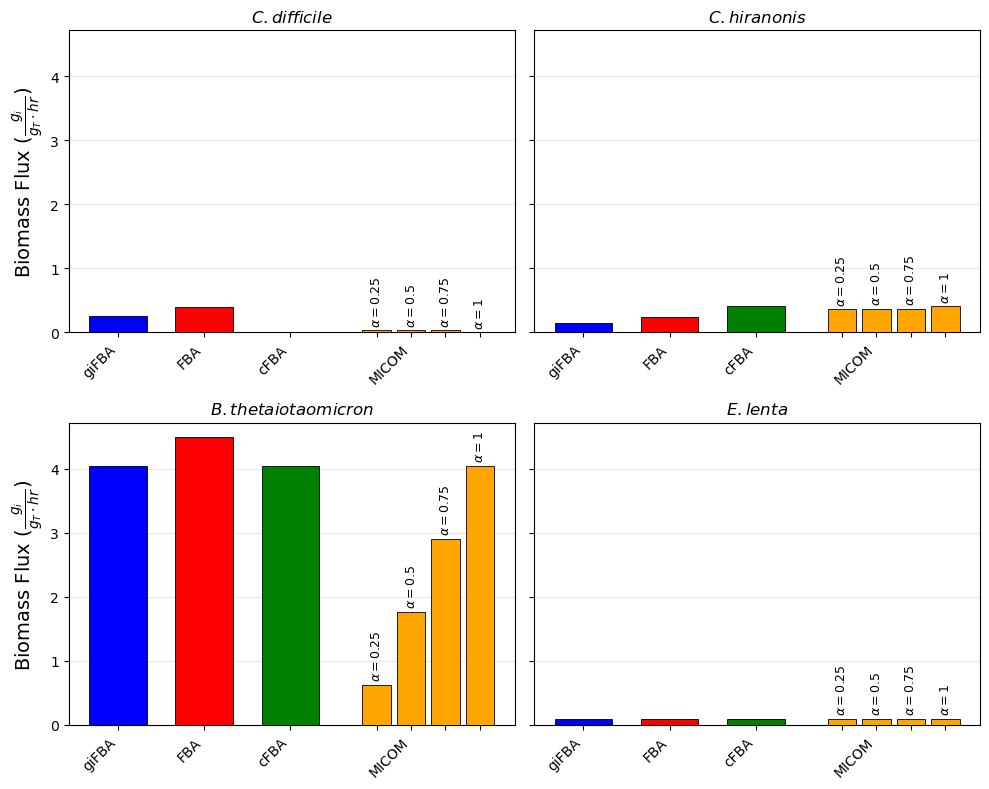

In [2]:
#plot model results
import gifba
import matplotlib.pyplot as plt
import numpy as np

# sizes for markers
fba_marker_size, cfba_marker_size, micom_marker_size = 100, 20, 50
gifba_marker_sizes = np.linspace(18, 4, community.iters)**2 * np.pi
micom_line_width = 0.5
colors = ["b", "r", "g", "orange"] # gifba, FBA, cFBA, MICOM

# extract cumulative growth for each organism
gifba_results = org_flux.loc[:]["EX_biomass(e)"]

# plot giFBA results for each org
fig, axs = plt.subplots(2,2, sharey=True, figsize=(10,8))
axs = axs.flatten()

# compared to cobrapy FBA
# reset model bounds, set media, simulate
# CD
media = community.media
fba_results = []
for org_model in models:
    with org_model as model:
        for ex in model.exchanges:
            model.exchanges.get_by_id(ex.id).lower_bound = 0
        for ex, flux in media.items():
            if ex in model.exchanges:
                model.exchanges.get_by_id(ex).lower_bound = flux
        fba_results.append(model.optimize().objective_value)


sim = "Cdiff_Community"
micom = pd.read_csv("Results/micom_results_real.csv", index_col=0)
micom = micom.loc[sim]
micom_tradeoffs = micom["tradeoff"]
micom = micom.loc[micom_tradeoffs.isin([0.25, 0.5, 0.75, 1.0])]
print(micom)
cfba = pd.read_csv(f"Results/cFBA/cFBA_results_{sim}.csv", index_col=False)
cfba = cfba[["First_Org_Flux", "Second_Org_Max_Flux", "3rd_Org_Max_Flux", "4th_Org_Max_Flux"]].values.flatten()

print(gifba_results)
print(fba_results)
print(micom)
print(cfba)
print()
def draw_ax_bar(num, name):
    cfba_cols = ["First_Org_Flux", "Second_Org_Max_Flux", "3rd_Org_Max_Flux", "4th_Org_Max_Flux"]
    micom_cols = [f"Org{i+1}_growth" for i in range(4)]
    data = np.zeros(7, dtype=float)
    data[:3] = [gifba_results[num], fba_results[num],cfba[num]]
    data[3:] = micom[micom_cols[num]].values.flatten()[::-1]
    print(data)
    x = [0,0.75, 1.5, 2.25, 2.55, 2.85, 3.15]
    ax = axs[num]

    ax.bar(
        x[:3], data[:3],
        width=0.5,
        color=colors[:3],
        edgecolor="black",
        linewidth=0.6,
        zorder=3
    )
    ax.bar(
        x[3:], data[3:],
        width=0.25,
        color=colors[3],
        edgecolor="black",
        linewidth=0.6,
        zorder=3
    )

    y_offset = 0.05
    for xi, yi, a in zip(x[3:], data[3:], [0.25, 0.5, 0.75, 1]):
        ax.text(
            xi, yi + y_offset,
            rf"$\alpha={a}$",
            ha="center", va="bottom",
            fontsize=9, color="k", rotation=90
    )

    labels=["giFBA", "FBA", "cFBA", 
       "", "MICOM", "", ""]
    
    axis_lab_size = 14
    ax.set_title(name)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.grid(axis="y", alpha=0.3, zorder=0)
    if num in [0,2]:
        ax.set_ylabel(r"Biomass Flux ($\frac{g_i}{g_T \cdot hr}$)", fontsize=axis_lab_size)


names = [r"$\it{C. difficile}$", r"$\it{C. hiranonis}$", r"$\it{B. thetaiotaomicron}$", r"$\it{E. lenta}$"]
for i, name in enumerate(names):
    draw_ax_bar(i, name)






plt.tight_layout()

plt.savefig("Results/giFBA_AGORA/gifba_4bactcomm.svg", bbox_inches='tight')

In [ ]:
summary = community.summarize()
edges, nodes = summary.to_cytoscape()

# generate community summary
summary = community.summarize()

# save to a cytoscape format
edge, node = summary.to_cytoscape()
edge.to_csv("4bact_comm_edges.csv")
node.to_csv("4bact_comm_nodes.csv")

# display summary
summary 

summary

Metabolite,Exchange,Flux,C-Number,C-Flux
fe2[e],EX_fe2(e),0.179362,0,0.00%
ocdca[e],EX_ocdca(e),0.044855,18,0.02%
cl[e],EX_cl(e),0.062743,0,0.00%
cys_L[e],EX_cys_L(e),1.574764,3,0.13%
phe_L[e],EX_phe_L(e),0.154520,9,0.04%
glu_L[e],EX_glu_L(e),0.604496,5,0.09%
pydx[e],EX_pydx(e),0.003775,8,0.00%
zn2[e],EX_zn2(e),0.062743,0,0.00%
mg2[e],EX_mg2(e),0.062743,0,0.00%
leu_L[e],EX_leu_L(e),0.438660,6,0.07%
